# Amazon ML Challenge 2026: Business Entity Resolution
## Exploratory Data Analysis & Visualization (Train Dataset)

This notebook provides visualisations and data quality checks for the training set:
- **Source 1** (`train_source1.tsv`): Deduplicated reference entities
- **Source 2** (`train_source2.tsv`): Candidate entities
- **Source 3** (`train_source3.tsv`): Candidate entities
- **Ground Truth** (`train_ground_truth.tsv`): True match mappings (`S1 -> [S2, S3]`)

In [1]:
import os
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

DATA_DIR = "data/student_resource/dataset/train"
if not os.path.exists(DATA_DIR):
    for p in ["/kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/dataset/train", "/kaggle/input/amazon-ml-challenge-2026/dataset/train", "student_resource/dataset/train"]:
        if os.path.exists(p):
            DATA_DIR = p
            break
print(f"Data directory: {DATA_DIR}")
print("Libraries loaded successfully!")

Libraries loaded successfully!


### 1. Load Training Datasets
> Note: Files are tab-separated (`sep="\t"`).

In [2]:
# Optional: Set to a float (e.g., 0.2 for 20%) for quick testing on large files
SAMPLE_FRAC = None

print("Loading TSV files...")
s1 = pd.read_csv(os.path.join(DATA_DIR, "train_source1.tsv"), sep="\t")
s2 = pd.read_csv(os.path.join(DATA_DIR, "train_source2.tsv"), sep="\t")
s3 = pd.read_csv(os.path.join(DATA_DIR, "train_source3.tsv"), sep="\t")
gt = pd.read_csv(os.path.join(DATA_DIR, "train_ground_truth.tsv"), sep="\t")

if SAMPLE_FRAC is not None and SAMPLE_FRAC < 1.0:
    s1 = s1.sample(frac=SAMPLE_FRAC, random_state=42).reset_index(drop=True)
    s2 = s2.sample(frac=SAMPLE_FRAC, random_state=42).reset_index(drop=True)
    s3 = s3.sample(frac=SAMPLE_FRAC, random_state=42).reset_index(drop=True)
    print(f"Sampled {SAMPLE_FRAC*100:.0f}% of records for rapid iteration.")

print(f"✓ Source 1 (Reference) : {len(s1):,} records")
print(f"✓ Source 2             : {len(s2):,} records")
print(f"✓ Source 3             : {len(s3):,} records")
print(f"✓ Ground Truth         : {len(gt):,} records")

Loading TSV files...
✓ Source 1 (Reference) : 2,206,821 records
✓ Source 2             : 5,034,616 records
✓ Source 3             : 5,285,603 records
✓ Ground Truth         : 2,206,821 records


### 2. Preview Samples

In [3]:
display("Source 1 Sample:", s1.head(3))
display("Ground Truth Sample:", gt.head(5))

'Source 1 Sample:'

,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US


'Ground Truth Sample:'

,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."


### 3. Record Counts & Ground Truth Match Distribution
- How many matches does each Source 1 entity have?
- Proportion of singletons (entities with 0 matches) vs entities with matches.

/var/folders/6w/m9t_z9qn7ts9831trydvtj8w0000gn/T/ipykernel_6416/2732457377.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(sizes.keys()), y=list(sizes.values()), ax=axes[0], palette="Blues_d")
/var/folders/6w/m9t_z9qn7ts9831trydvtj8w0000gn/T/ipykernel_6416/2732457377.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(grouped_counts.keys()), y=list(grouped_counts.values()), ax=axes[1], palette="magma")


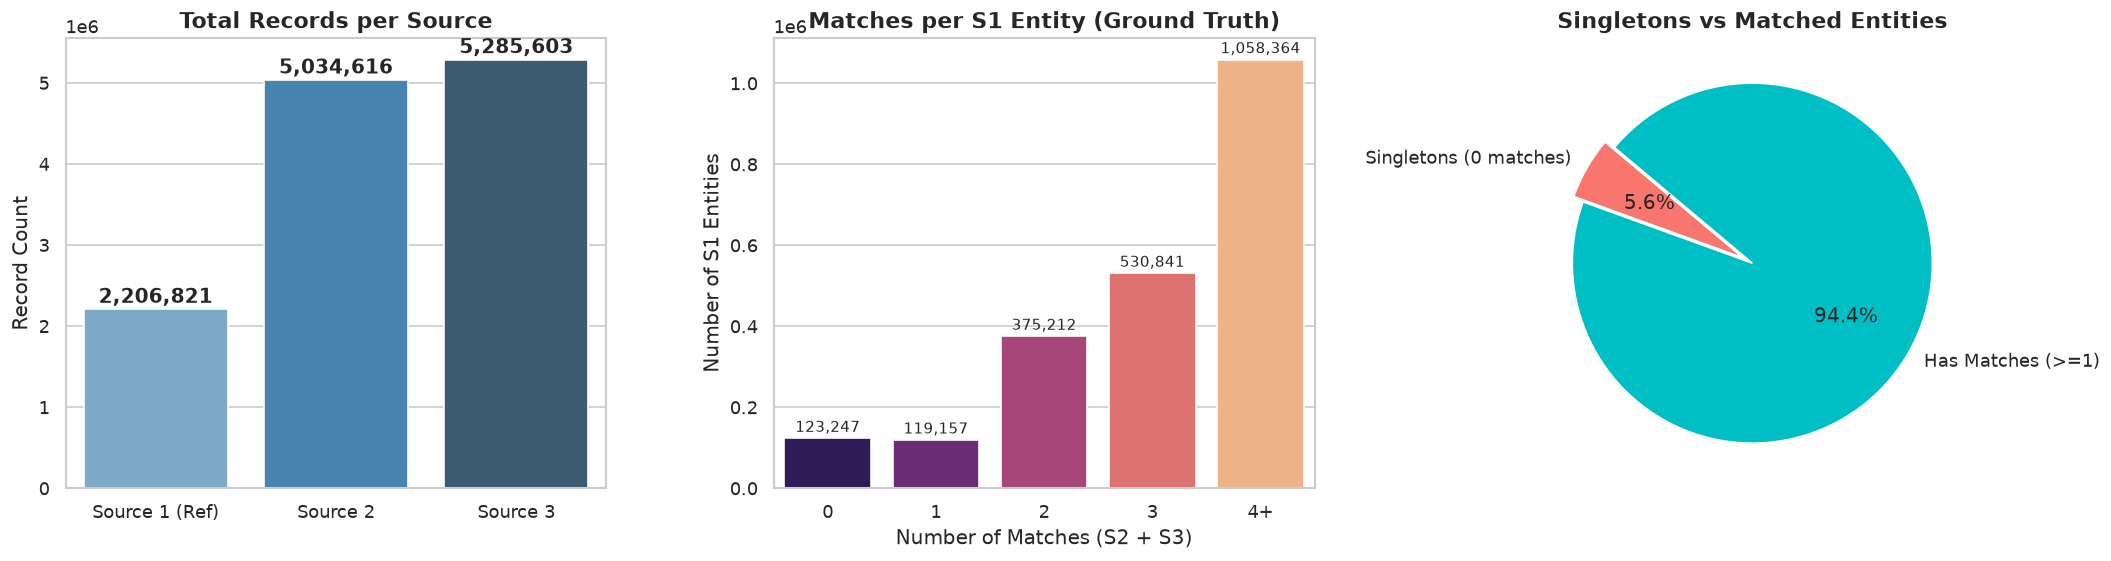

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Total records per source
sizes = {"Source 1 (Ref)": len(s1), "Source 2": len(s2), "Source 3": len(s3)}
sns.barplot(x=list(sizes.keys()), y=list(sizes.values()), ax=axes[0], palette="Blues_d")
axes[0].set_title("Total Records per Source", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Record Count")
for i, (k, v) in enumerate(sizes.items()):
    axes[0].text(i, v + (max(sizes.values()) * 0.015), f"{v:,}", ha="center", fontweight="bold")

# 2. Number of matches per S1 entity
gt["match_count"] = gt["matched_entity_ids"].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip() == "" else len(str(x).split(","))
)
count_bins = gt["match_count"].value_counts().sort_index()

# Group counts for 4 or more matches
grouped_counts = count_bins[count_bins.index < 4].to_dict()
grouped_counts["4+"] = count_bins[count_bins.index >= 4].sum()

sns.barplot(x=list(grouped_counts.keys()), y=list(grouped_counts.values()), ax=axes[1], palette="magma")
axes[1].set_title("Matches per S1 Entity (Ground Truth)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Matches (S2 + S3)")
axes[1].set_ylabel("Number of S1 Entities")
for i, (k, v) in enumerate(grouped_counts.items()):
    axes[1].text(i, v + (max(grouped_counts.values()) * 0.015), f"{v:,}", ha="center", fontsize=9)

# 3. Pie chart: Singletons vs Matched Entities
singletons = (gt["match_count"] == 0).sum()
matched = (gt["match_count"] > 0).sum()
axes[2].pie(
    [singletons, matched],
    labels=["Singletons (0 matches)", "Has Matches (>=1)"],
    autopct="%1.1f%%",
    colors=["#f8766d", "#00bfc4"],
    startangle=140,
    explode=(0.06, 0)
)
axes[2].set_title("Singletons vs Matched Entities", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

### 4. Matches Origin Breakdown (Source 2 vs Source 3)

In [ ]:
def classify_matches(matched_str):
    if pd.isna(matched_str) or str(matched_str).strip() == "":
        return "No Match (Singleton)"
    ids = [x.strip() for x in str(matched_str).split(",")]
    has_s2 = any(i.startswith("S2-") for i in ids)
    has_s3 = any(i.startswith("S3-") for i in ids)
    if has_s2 and has_s3:
        return "Both (S2 & S3)"
    elif has_s2:
        return "Only S2"
    elif has_s3:
        return "Only S3"
    return "Other"

gt["source_split"] = gt["matched_entity_ids"].apply(classify_matches)
split_counts = gt["source_split"].value_counts()

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(x=split_counts.index, y=split_counts.values, palette="crest")
plt.title("Distribution of Matches by Source Origin", fontsize=13, fontweight="bold")
plt.ylabel("Number of S1 Entities")
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:,}\n({height/len(gt)*100:.1f}%)", 
                (p.get_x() + p.get_width() / 2., height / 2),
                ha="center", va="center", color="white", fontweight="bold")
plt.tight_layout()
plt.show()

### 5. Country Distribution Across Sources

In [ ]:
dfs = []
for name, df in [("Source 1", s1), ("Source 2", s2), ("Source 3", s3)]:
    counts = df["country"].value_counts(normalize=True).reset_index()
    counts.columns = ["Country", "Proportion"]
    counts["Source"] = name
    dfs.append(counts)

combined_country = pd.concat(dfs, ignore_index=True)

plt.figure(figsize=(7, 4.5))
ax = sns.barplot(data=combined_country, x="Country", y="Proportion", hue="Source", palette="Set2")
plt.title("Country Breakdown Across Sources", fontsize=13, fontweight="bold")
plt.ylabel("Proportion")
plt.ylim(0, 1.05)
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h*100:.1f}%", (p.get_x() + p.get_width() / 2., h + 0.015), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### 6. Text Length & Word Count Distributions

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for name, df in [("S1", s1), ("S2", s2), ("S3", s3)]:
    name_chars = df["business_name"].fillna("").str.len()
    addr_chars = df["business_address"].fillna("").str.len()
    name_words = df["business_name"].fillna("").str.split().str.len()
    addr_words = df["business_address"].fillna("").str.split().str.len()

    sns.kdeplot(name_chars, label=name, ax=axes[0, 0], clip=(0, 100), common_norm=False)
    sns.kdeplot(addr_chars, label=name, ax=axes[0, 1], clip=(0, 200), common_norm=False)
    sns.kdeplot(name_words, label=name, ax=axes[1, 0], clip=(0, 15), common_norm=False)
    sns.kdeplot(addr_words, label=name, ax=axes[1, 1], clip=(0, 35), common_norm=False)

axes[0, 0].set_title("Business Name Character Length (KDE)", fontweight="bold")
axes[0, 0].set_xlabel("Characters")
axes[0, 0].legend()

axes[0, 1].set_title("Business Address Character Length (KDE)", fontweight="bold")
axes[0, 1].set_xlabel("Characters")
axes[0, 1].legend()

axes[1, 0].set_title("Business Name Word Count (KDE)", fontweight="bold")
axes[1, 0].set_xlabel("Number of Words")
axes[1, 0].legend()

axes[1, 1].set_title("Business Address Word Count (KDE)", fontweight="bold")
axes[1, 1].set_xlabel("Number of Words")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 7. Common Business Name Suffixes / Top Tokens

In [ ]:
def get_top_tokens(series, n=15):
    words = series.dropna().str.lower().str.replace(r"[^\w\s]", "", regex=True).str.split()
    counter = Counter([w for sublist in words for w in sublist if len(w) > 1])
    return pd.DataFrame(counter.most_common(n), columns=["Token", "Count"])

top_tokens = get_top_tokens(s1["business_name"], n=15)

plt.figure(figsize=(9, 4.5))
sns.barplot(data=top_tokens, x="Count", y="Token", palette="mako")
plt.title("Top 15 Most Common Tokens in Source 1 Business Names", fontsize=13, fontweight="bold")
plt.xlabel("Occurrences")
plt.tight_layout()
plt.show()

### 8. Side-by-Side Match Inspector
Review sample Source 1 reference records and compare them directly against their matched records in Source 2 and Source 3.

In [ ]:
def inspect_matches(s1_df, s2_df, s3_df, gt_df, n_samples=3):
    s1_map = s1_df.set_index("entity_id").to_dict(orient="index")
    s2_map = s2_df.set_index("entity_id").to_dict(orient="index")
    s3_map = s3_df.set_index("entity_id").to_dict(orient="index")
    
    matched_gt = gt_df[gt_df["match_count"] > 0].sample(n_samples, random_state=42)
    
    for _, row in matched_gt.iterrows():
        s1_id = row["source1_entity_id"]
        s1_info = s1_map.get(s1_id, {})
        match_ids = [m.strip() for m in row["matched_entity_ids"].split(",")]
        
        print("=" * 80)
        print(f"📌 [REFERENCE] {s1_id} | Country: {s1_info.get('country')}")
        print(f"   Name   : {s1_info.get('business_name')}")
        print(f"   Address: {s1_info.get('business_address')}")
        print("-" * 80)
        print(f"🔗 MATCHED RECORDS ({len(match_ids)} found):")
        for m_id in match_ids:
            pool = s2_map if m_id.startswith("S2-") else s3_map
            m_info = pool.get(m_id, {})
            print(f"   -> [{m_id}] ({m_info.get('country')})")
            print(f"      Name   : {m_info.get('business_name')}")
            print(f"      Address: {m_info.get('business_address')}")
        print("=" * 80 + "\n")

inspect_matches(s1, s2, s3, gt, n_samples=3)

## 9. Comprehensive Feature Extraction & Normalization Pipeline

Implementing the multi-tier preparation pipeline for blocking and entity matching:
1. **Pre-Cleaning State Extraction & Mapping** (US & India full state mapping, 2-letter abbreviations, native scripts)
2. **Universal Text Cleaning** (Accents/Unicode removal, lowercasing, symbol expansion, punctuation cleaning)
3. **Business Name Normalization** (Industry abbreviations, phonetic transliterations, and core brand extraction)
4. **Address Normalization** (Road types, directions, unit numbers, landmarks)


In [ ]:
# Install required packages for progress tracking and Unicode script transliteration
!pip install -q tqdm unidecode


In [ ]:
import re
import unicodedata
from unidecode import unidecode

# ==============================================================================
# Tier 0: State Extraction & Standardization (Pre-Cleaning)
# Maps US & India states, short abbreviations, and native scripts to full state names
# ==============================================================================

US_STATE_ABBREV_TO_FULL = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
    'DC': 'District of Columbia'
}

INDIA_STATE_ABBREV_TO_FULL = {
    'AP': 'Andhra Pradesh', 'AR': 'Arunachal Pradesh', 'AS': 'Assam', 'BR': 'Bihar',
    'CG': 'Chhattisgarh', 'GA': 'Goa', 'GJ': 'Gujarat', 'HR': 'Haryana', 'HP': 'Himachal Pradesh',
    'JH': 'Jharkhand', 'KA': 'Karnataka', 'KL': 'Kerala', 'MP': 'Madhya Pradesh', 'MH': 'Maharashtra',
    'MN': 'Manipur', 'ML': 'Meghalaya', 'MZ': 'Mizoram', 'NL': 'Nagaland', 'OD': 'Odisha',
    'PB': 'Punjab', 'RJ': 'Rajasthan', 'SK': 'Sikkim', 'TN': 'Tamil Nadu', 'TS': 'Telangana',
    'TG': 'Telangana', 'TR': 'Tripura', 'UP': 'Uttar Pradesh', 'UK': 'Uttarakhand', 'UA': 'Uttarakhand',
    'WB': 'West Bengal', 'DL': 'Delhi', 'JK': 'Jammu and Kashmir', 'LA': 'Ladakh', 'PY': 'Puducherry', 'CH': 'Chandigarh'
}

INDIA_NATIVE_TO_FULL = {
    'ಕರ್ನಾಟಕ': 'Karnataka', 'महाराष्ट्र': 'Maharashtra', 'बिहार': 'Bihar',
    'తెలంగాణ': 'Telangana', 'தமிழ்நாடு': 'Tamil Nadu', 'ગુજરાત': 'Gujarat',
    'उत्तर प्रदेश': 'Uttar Pradesh', 'पश्चिम बंगाल': 'West Bengal', 'केरल': 'Kerala',
    'दिल्ली': 'Delhi', 'राजस्थान': 'Rajasthan', 'मध्य प्रदेश': 'Madhya Pradesh',
    'पंजाब': 'Punjab', 'हरियाणा': 'Haryana', 'ఆంధ్ర ప్రదేశ್': 'Andhra Pradesh',
    'পশ্চিমবঙ্গ': 'West Bengal', 'বাংলা': 'West Bengal', 'ஒடிசா': 'Odisha'
}

FRANCE_REGIONS = [
    'Auvergne-Rhône-Alpes', 'Bourgogne-Franche-Comté', 'Bretagne', 'Centre-Val de Loire',
    'Corse', 'Grand Est', 'Hauts-de-France', 'Île-de-France', 'Normandie', 'Nouvelle-Aquitaine',
    'Occitanie', 'Pays de la Loire', "Provence-Alpes-Côte d'Azur", 'Guadeloupe', 'Martinique',
    'Guyane', 'La Réunion', 'Mayotte'
]

# Case-insensitive lookup dictionaries
US_LOOKUP = {k.lower(): v for k, v in US_STATE_ABBREV_TO_FULL.items()}
for v in US_STATE_ABBREV_TO_FULL.values():
    US_LOOKUP[v.lower()] = v

INDIA_LOOKUP = {k.lower(): v for k, v in INDIA_STATE_ABBREV_TO_FULL.items()}
for v in INDIA_STATE_ABBREV_TO_FULL.values():
    INDIA_LOOKUP[v.lower()] = v
INDIA_LOOKUP['tamilnadu'] = 'Tamil Nadu'
INDIA_LOOKUP['orissa'] = 'Odisha'
INDIA_LOOKUP['uttaranchal'] = 'Uttarakhand'
INDIA_LOOKUP['pondicherry'] = 'Puducherry'
INDIA_LOOKUP['new delhi'] = 'Delhi'

FRANCE_LOOKUP = {r.lower(): r for r in FRANCE_REGIONS}

def extract_state_info(addr, country="US"):
    """
    Extracts full standardized state name from raw address prior to text cleaning.
    Returns: (state_name, has_state_flag)
      - state_name: Full state name (e.g. 'North Carolina', 'Karnataka') or None
      - has_state_flag: 1 if state was found, 0 if false
    """
    if not isinstance(addr, str) or not addr.strip():
        return (None, 0)
    
    country = str(country).strip()
    
    # 1. Native script check (India)
    if country == "India":
        for native, full_name in INDIA_NATIVE_TO_FULL.items():
            if native in addr:
                return (full_name, 1)

    # 2. Comma token analysis (most reliable: last part, second to last part, first part)
    parts = [p.strip() for p in addr.split(',') if p.strip()]
    check_tokens = []
    if len(parts) >= 1:
        check_tokens.append(parts[-1])
    if len(parts) >= 2:
        check_tokens.append(parts[-2])
    if len(parts) >= 3:
        check_tokens.append(parts[0])

    if country == "US":
        for tok in check_tokens:
            cleaned_tok = re.sub(r'[^a-zA-Z\s]', '', tok).strip().lower()
            if cleaned_tok in US_LOOKUP:
                return (US_LOOKUP[cleaned_tok], 1)
        for k, v in US_LOOKUP.items():
            if len(k) > 2 and re.search(r'\b' + re.escape(k) + r'\b', addr, re.IGNORECASE):
                return (v, 1)
        match = re.search(r'\b([A-Z]{2})\b', addr)
        if match and match.group(1).lower() in US_LOOKUP:
            return (US_LOOKUP[match.group(1).lower()], 1)

    elif country == "India":
        for tok in check_tokens:
            cleaned_tok = re.sub(r'[^a-zA-Z\s]', '', tok).strip().lower()
            if cleaned_tok in INDIA_LOOKUP:
                return (INDIA_LOOKUP[cleaned_tok], 1)
        for k, v in INDIA_LOOKUP.items():
            if len(k) > 2 and re.search(r'\b' + re.escape(k) + r'\b', addr, re.IGNORECASE):
                return (v, 1)
        for tok in parts:
            c = tok.strip().lower()
            if c in INDIA_LOOKUP and len(c) == 2:
                return (INDIA_LOOKUP[c], 1)

    elif country == "France":
        for r_lower, r_full in FRANCE_LOOKUP.items():
            if r_lower in addr.lower():
                return (r_full, 1)

    return (None, 0)

# ==============================================================================
# Tier 1 & 2: Text Normalization Pipeline
# ==============================================================================

def clean_universal(text):
    """
    Tier 1 Enhanced: Universal text hygiene handling all 8 major dataset noise patterns:
    1. Appended URL stripping ("WEST LTD | www.westltd.com" -> "WEST LTD")
    2. Explicit URL & prefix removal (www., http://)
    3. Leading handle & hashtag removal (@handle, #name)
    4. Domain extension removal (.com, .org, .net, etc.)
    5. Script transliteration (Devanagari, Tamil, Telugu & European accents to phonetic ASCII)
    6. Leetspeak / OCR digit-to-letter normalization (0 -> o, 1 -> l inside words)
    7. Parenthetical annotation unwrapping ("(India)" -> "India")
    8. Symbol hygiene & whitespace normalization
    """
    if not isinstance(text, str) or not text.strip():
        return ""
        
    # 1. Strip pipe/slash appended URLs or metadata
    text = re.sub(r"\s*\|\s*(?:www\.|https?://|\S+\.(?:com|org|net|in|co|io))\S*", "", text, flags=re.IGNORECASE)
    
    # 2. Strip explicit URLs and prefixes
    text = re.sub(r"https?://\S+|www\.\S+", "", text, flags=re.IGNORECASE)
    
    # 3. Strip leading handle/hashtag symbols (@, #, *)
    text = re.sub(r"^\s*[@#*]+\s*", "", text)
    
    # 4. Strip domain extensions (.com, .org, .net, etc.)
    text = re.sub(r"\.(com|org|net|in|co|io|biz|info|us|edu|gov)\b", " ", text, flags=re.IGNORECASE)
    
    # 5. Strip possessives: e.g. "Orelee's" -> "Orelee" (prevents rogue standalone 's' tokens)
    text = re.sub(r"['’]s\b", "", text, flags=re.IGNORECASE)
    
    # 5. Transliterate Unicode scripts (Indic languages, French/Spanish accents) to Latin/ASCII
    text = unidecode(text).lower()
    
    # 6. Leetspeak / OCR digit-to-letter normalization
    text = re.sub(r"(?<=[a-z])0(?=[a-z])", "o", text)
    text = re.sub(r"(?<=[a-z])1(?=[a-z])", "l", text)
    
    # 7. Unwrap parenthetical annotations: "(India)" -> "India"
    text = re.sub(r"[\(\[\{]([^\)\]\}]+)[\)\]\}]", r" \1 ", text)
    
    # 8. Standard symbols & whitespace
    text = re.sub(r"\s*&\s*", " and ", text)
    text = re.sub(r"\s*\+\s*", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

# Phonetic & spelling harmonization patterns (preserving brand identity across variations)
SPELLING_HARMONIZATION = [
    (r"\blaxmi\b", "lakshmi"),
    (r"\b(choudhary|choudhury|chowdhury)\b", "chaudhary"),
    (r"\bbikas\b", "vikas"),
    (r"\bparsad\b", "prasad"),
]

# Suffix and Prefix Removal Patterns (Legal forms, generic business descriptors, noisy stopwords)
# Completely stripped during preprocessing to stop excessive false matching
SUFFIX_PREFIX_REMOVE_PATTERNS = [
    # 1. Multi-word & single-word legal forms
    r"\b(private limited|pvt ltd|pvt limited|private ltd|praaivett limittedd|praiveett limittedd|piraiveett limittett|elelpii)\b",
    r"\b(limited liability company|limited liability co|llc|pllc|llp)\b",
    r"\b(incorporated|corporation|inc|corp)\b",
    r"\b(limited|ltd|company|co|public|foundation|trust)\b",
    r"\b(sarl|sas|sa|eurl|snc)\b",
    # 2. Web domains / handles
    r"\b(com|org|net)\b",
    # 3. Commercial & corporate entity descriptors
    r"\b(enterprises|enterprise|industries|industry)\b",
    r"\b(solutions|services|service|svc|serv)\b",
    r"\b(holdings|holding|group|grp|associates|assoc|brothers|bros|sons|son|partners)\b",
    r"\b(ventures|capital|trading|traders|exports|marketing|management|mgmt)\b",
    r"\b(products|agency|firm)\b",
    # 4. Tech & Engineering & Infrastructure descriptors
    r"\b(technologies|technology|tech|techno|systems|system|engineering|engg|infratech|infra)\b",
    # 5. Consulting & Advisory descriptors
    r"\b(consulting|consultancy|consultants|consultant|advisory|advisors)\b",
    # 6. Medical & Healthcare descriptors
    r"\b(medicine|medical|clinic|care|health|healthcare|dental|hospital|pediatric|specialists|physicians|pharmaceuticals|pharma)\b",
    # 7. Retail & Facility descriptors
    r"\b(center|centre|business|store|shop|barbershop|salon|bazaar|market|mart)\b",
    # 8. Education & Institutional descriptors
    r"\b(institute|institution|school|academy|society)\b",
    # 9. Broad geographic/scope words
    r"\b(international|intl|int|global|national|metro|india)\b",
    # 10. Indian honorific prefixes
    r"\b(sri|shri|smt)\b",
    # 11. Noisy stopwords & prefixes
    r"\b(the|and|of|in|at|for|to|a|an)\b",
]

def normalize_name(name):
    """Tier 2: Business name spelling harmonization and suffix/prefix removal."""
    clean = clean_universal(name)
    for pattern, repl in SPELLING_HARMONIZATION:
        clean = re.sub(pattern, repl, clean)
    for pattern in SUFFIX_PREFIX_REMOVE_PATTERNS:
        clean = re.sub(pattern, " ", clean)
    clean = re.sub(r"\s+", " ", clean).strip()
    return clean if len(clean) >= 1 else clean_universal(name)

# def extract_core_name(name):
#     """Tier 2b: Extracts distinctive core brand tokens by completely stripping suffixes and prefixes."""
#     norm = normalize_name(name)
#     for pattern in SUFFIX_PREFIX_REMOVE_PATTERNS:
#         norm = re.sub(pattern, " ", norm)
#     norm = re.sub(r"\s+", " ", norm).strip()
#     return norm if len(norm) > 1 else clean_universal(name)

ADDR_EXPANSIONS = [
    (r"\b(st|str)\b", "street"),
    (r"\b(rd|marg|rasta)\b", "road"),
    (r"\b(ave|av)\b", "avenue"),
    (r"\bblvd\b", "boulevard"),
    (r"\bhwy\b", "highway"),
    (r"\bdr\b", "drive"),
    (r"\bln\b", "lane"),
    (r"\bct\b", "court"),
    (r"\bpkwy\b", "parkway"),
    (r"\bn\b", "north"),
    (r"\bs\b", "south"),
    (r"\be\b", "east"),
    (r"\bw\b", "west"),
    (r"\bne\b", "northeast"),
    (r"\bnw\b", "northwest"),
    (r"\bse\b", "southeast"),
    (r"\bsw\b", "southwest"),
    (r"\b(ste|ste#|suite#)\b", "suite"),
    (r"\b(apt|flat)\b", "apartment"),
    (r"\b(fl|flr)\b", "floor"),
    (r"\b(gr flr|gf)\b", "ground floor"),
    (r"\bbldg\b", "building"),
    (r"\b(plt|plot no)\b", "plot"),
    (r"\b(sec|sector no)\b", "sector"),
    (r"\b(opp|opp to|opposite to)\b", "opposite"),
    (r"\b(nr|near to)\b", "near"),
    (r"\bbehind\b", "behind"),
]

def normalize_address(addr):
    """Tier 3: Address standardization across abbreviations, landmarks, and street types."""
    clean = clean_universal(addr)
    for pattern, repl in ADDR_EXPANSIONS:
        clean = re.sub(pattern, repl, clean)
    return re.sub(r"\s+", " ", clean).strip()

print("✓ Feature extraction & normalization pipeline defined successfully!")


### 10. Test Normalization on Tricky & Cross-Lingual Edge Cases
Reviewing before and after across French accents, Indian landmarks, and US corporate abbreviations.

In [ ]:
test_cases = [
    # Standard US & Indian business names
    ("Orelee's Barbershop", "1795 Westchester Drive, High Point, NC", "US"),
    ("Apex Technologies Corp.", "Suite 300, 1420 N. Main St., Dallas, TX 75201", "US"),
    ("Sharma Sweets Pvt. Ltd.", "Shop 4, Opp. Metro Pillar 54, Sector 18, Noida 201301", "India"),
    # Accented Latin characters (deliberate noise in challenge)
    ("Private Ambernath Sólar Limited", "Ambernath MIDC, Thane, Maharashtra", "India"),
    ("OX Innovation Private Límited", "12 MG Road, Bangalore, Karnataka", "India"),
    # Indic native scripts (Devanagari, Tamil)
    ("राम मार्केटिंग प्राइवेट लिमिटेड", "चांदनी चौक, नई दिल्ली, दिल्ली", "India"),
    ("குளோபல் பிசினஸ் பிரைவேட் லிமிடெட்", "அண்ணா சாலை, சென்னை, தமிழ்நாடு", "India"),
    # Appended URLs and Web domains
    ("WEST LTD (COURIERS) | www.westltd.com", "100 Broadway, New York, NY", "US"),
    ("@primemoney", "17560 Ellis Rd, Tahlequah, Oklahoma", "US"),
    ("moorebitwise.com", "0337 Oakland Avenue, Michigan City, Indiana", "US"),
    # Leetspeak / OCR digit-for-letter substitution
    ("DIAM0ND BEACON DOUGLAS", "1420 N Main St, Dallas TX", "US"),
    ("Lewis, Fog1eman & Lambert LLP", "Market St, San Francisco, CA", "US"),
    # Parenthetical annotations
    ("Osprey (India) Development LLP", "Infopark, Kochi, Kerala", "India"),
]

print(f"{'RAW NAME':<40} | {'CLEAN NAME':<24} | {'STATE (FULL)':<16} | {'CLEAN ADDRESS':<40}")
print("-" * 125)
for name, addr, country in test_cases:
    c_clean = normalize_name(name)
    c_addr = normalize_address(addr)
    state, has_st = extract_state_info(addr, country)
    print(f"{name:<40} | {c_clean:<24} | {str(state):<16} | {c_addr:<40}")


### 11. Add State Extraction, Cleaning & Business Name Splitting In-Place
Applies the preprocessing pipeline directly to the loaded , , and  DataFrames:
1. **State Extraction**: Resolves standardized state names from raw addresses before cleaning.
2. **Text Normalization**: Adds cleaned name and address (, ).
3. **Word Splitting (12 Words Limit)**: Splits `clean_name` into individual word columns (`name_word_1` through `name_word_12`) directly in the DataFrame.

In [ ]:
from tqdm.auto import tqdm

def add_features_in_place(df, name="dataset", max_words=12):
    """
    Extracts states, cleans text, and splits business names into up to 12 word columns,
    modifying the existing loaded DataFrame in-place without copying or creating new DataFrames.
    """
    print(f"\n--- Adding features in-place to {name} ({len(df):,} records): State Extraction, Cleaning & Word Splitting ---")

    # 0. Deduplicate any duplicate columns in-place (safe for re-runs)
    if df.columns.has_duplicates:
        new_cols = []
        seen = set()
        for col in df.columns:
            if col in seen:
                new_cols.append(f"__DROP_DUP_{len(new_cols)}__")
            else:
                seen.add(col)
                new_cols.append(col)
        df.columns = new_cols
        drop_cols = [c for c in new_cols if c.startswith("__DROP_DUP_")]
        if drop_cols:
            df.drop(columns=drop_cols, inplace=True)

    # 1. State Extraction before address cleaning
    print(f"[{name}] Extracting states from raw address...")
    state_tuples = [extract_state_info(addr, country) for addr, country in zip(df["business_address"], df["country"])]
    df["state"] = [t[0] for t in state_tuples]
    df["has_state"] = [t[1] for t in state_tuples]

    # 2. Text Normalization
    b_names = df["business_name"].fillna("").astype(str)
    b_addrs = df["business_address"].fillna("").astype(str)

    tqdm.pandas(desc=f"[{name}] Clean Names")
    df["clean_name"] = b_names.progress_apply(normalize_name)

    # Core name extraction commented out (clean_name is already fully normalized and stripped)
    # df["core_name"] = b_names.progress_apply(extract_core_name)

    tqdm.pandas(desc=f"[{name}] Clean Addresses")
    df["clean_address"] = b_addrs.progress_apply(normalize_address)

    # 3. Dynamic Word Splitting (Up to 12 words) from clean_name
    print(f"[{name}] Splitting business name words (limit={max_words})...")
    
    # Drop any existing word columns before re-assigning (safe for re-runs)
    existing_word_cols = [c for c in df.columns if c.startswith("name_word_")]
    if existing_word_cols:
        df.drop(columns=list(dict.fromkeys(existing_word_cols)), inplace=True)

    df["name_words"] = df["clean_name"].astype(str).str.split(" ")
    words_split = df["clean_name"].astype(str).str.split(" ", expand=True)
    n_cols = min(max_words, words_split.shape[1])
    
    # Assign column by column to guarantee exact key-length matching
    for i in range(n_cols):
        df[f"name_word_{i+1}"] = words_split[i]

    return df

# Add features directly to existing loaded DataFrames s1, s2, s3 in-place
add_features_in_place(s1, "Source 1", max_words=12)
add_features_in_place(s2, "Source 2", max_words=12)
add_features_in_place(s3, "Source 3", max_words=12)

print("\n✓ Features successfully added in-place to existing DataFrames s1, s2, and s3!")
word_cols_s1 = [c for c in s1.columns if c.startswith("name_word_")]
preview_cols = ["entity_id", "country", "state", "has_state", "clean_name"] + word_cols_s1
display("Source 1 Sample (In-Place Features):", s1[preview_cols].head(3))


### 12. Candidate Blocking & Multi-Signal Scoring (Country Match → Scoring & Ranking → Top 15)
Generates high-recall, bounded candidate sets for each  record:

1. **Initial Candidate Pool (Country Match)**: Filter candidates in  and  where .
2. **Signal Retrieval**: Bypasses zero-overlap noise by indexing candidates with at least 1 Name token (or concatenated domain) OR Address token.
3. **Multi-Signal Scoring Breakdown**: Evaluates candidate relevance using weighted scoring metrics:
   - : Count of common words between clean business names (, weight **2.0x**).
   - : Count of common words between normalized addresses (, weight **1.0x**).
   - :  if both S1 and candidate have a known state and they match,  otherwise (weight **1.0x**).
   - **** = 
4. **Top 15 Ranking**: Sorts candidates by  descending and retains the top **15** candidates per S1 record.


In [ ]:
def block_candidates(s1_subset, s2_df, s3_df, max_words=12, top_k=15):
    """
    Candidate Blocking & Multi-Signal Scoring for each S1 record:
      1. Country Match: Initial pool is partitioned by candidate['country'] == s1['country']
      2. Signal Retrieval: Filters candidates matching any clean brand token (or domain) OR address token
      3. Multi-Signal Scoring:
         - name_overlap_count: count of overlapping words between clean names (len >= 1)
         - address_overlap_count: count of overlapping words between clean addresses (len > 1)
         - state_match: 1 if both have state and they match, else 0
         - matching_score = 2.0 * name_overlap_count + 1.0 * address_overlap_count + 1.0 * state_match
      4. Best 15 Selection: Keep top 15 highest-scoring candidates per S1 record
    """
    word_cols = [f"name_word_{i+1}" for i in range(max_words)]
    s2_avail = [c for c in word_cols if c in s2_df.columns]
    s3_avail = [c for c in word_cols if c in s3_df.columns]
    
    name_col_s2 = 'clean_name' if 'clean_name' in s2_df.columns else ('core_name' if 'core_name' in s2_df.columns else 'business_name')
    name_col_s3 = 'clean_name' if 'clean_name' in s3_df.columns else ('core_name' if 'core_name' in s3_df.columns else 'business_name')
    addr_col_s2 = 'clean_address' if 'clean_address' in s2_df.columns else 'business_address'
    addr_col_s3 = 'clean_address' if 'clean_address' in s3_df.columns else 'business_address'
    
    s2_select_cols = ['entity_id', 'country', 'business_name', name_col_s2, addr_col_s2, 'state'] + s2_avail
    s3_select_cols = ['entity_id', 'country', 'business_name', name_col_s3, addr_col_s3, 'state'] + s3_avail
    
    blocking_summary = []
    blocked_candidates = {}
    
    for _, s1_row in s1_subset.iterrows():
        s1_id = s1_row['entity_id']
        s1_country = s1_row['country']
        s1_state = s1_row.get('state')
        s1_has_state = s1_row.get('has_state', 1 if pd.notna(s1_state) else 0)
        
        s1_clean_name = str(s1_row.get('clean_name', s1_row.get('core_name', s1_row['business_name'])))
        s1_name_words = set(w for w in s1_clean_name.split() if len(w) >= 1)
        s1_clean_addr = str(s1_row.get('clean_address', s1_row.get('business_address', '')))
        s1_addr_words = set(w for w in s1_clean_addr.split() if len(w) > 1)
        
        # Word pool for fast candidate retrieval
        s1_words = [
            str(s1_row[c]).strip() for c in word_cols 
            if c in s1_row and pd.notna(s1_row[c]) and len(str(s1_row[c]).strip()) >= 1
        ]
        s1_word_set = set(s1_words) if s1_words else s1_name_words
        # Also add concatenated brand words to match domain/handle candidates (e.g. primemoney, moorebitwise)
        s1_joined = "".join(s1_words) if len(s1_words) >= 2 else None
        if s1_joined:
            s1_word_set.add(s1_joined)
            
        # Significant address tokens to search (excluding single-char noise)
        addr_tokens = [w for w in s1_addr_words if len(w) >= 2][:15]
        addr_pat = r'\b(?:' + '|'.join(re.escape(w) for w in addr_tokens) + r')\b' if addr_tokens else None
        
        # 1. Match against S2 (Initial pool: Country match + signal retrieval)
        s2_c_mask = (s2_df['country'] == s1_country)
        s2_cand_sub = s2_df[s2_c_mask]
        
        s2_name_mask = s2_cand_sub[s2_avail].isin(s1_word_set).any(axis=1) if s1_word_set else pd.Series(False, index=s2_cand_sub.index)
        if addr_pat:
            s2_addr_mask = s2_cand_sub[addr_col_s2].fillna('').astype(str).str.contains(addr_pat, regex=True)
            s2_matches = s2_cand_sub[s2_name_mask | s2_addr_mask][s2_select_cols].copy()
        else:
            s2_matches = s2_cand_sub[s2_name_mask][s2_select_cols].copy()
            
        s2_matches['source'] = 'S2'
        if name_col_s2 != 'clean_name':
            s2_matches.rename(columns={name_col_s2: 'clean_name'}, inplace=True)
        if addr_col_s2 != 'clean_address':
            s2_matches.rename(columns={addr_col_s2: 'clean_address'}, inplace=True)
            
        # 2. Match against S3 (Initial pool: Country match + signal retrieval)
        s3_c_mask = (s3_df['country'] == s1_country)
        s3_cand_sub = s3_df[s3_c_mask]
        
        s3_name_mask = s3_cand_sub[s3_avail].isin(s1_word_set).any(axis=1) if s1_word_set else pd.Series(False, index=s3_cand_sub.index)
        if addr_pat:
            s3_addr_mask = s3_cand_sub[addr_col_s3].fillna('').astype(str).str.contains(addr_pat, regex=True)
            s3_matches = s3_cand_sub[s3_name_mask | s3_addr_mask][s3_select_cols].copy()
        else:
            s3_matches = s3_cand_sub[s3_name_mask][s3_select_cols].copy()
            
        s3_matches['source'] = 'S3'
        if name_col_s3 != 'clean_name':
            s3_matches.rename(columns={name_col_s3: 'clean_name'}, inplace=True)
        if addr_col_s3 != 'clean_address':
            s3_matches.rename(columns={addr_col_s3: 'clean_address'}, inplace=True)
            
        matched_cands = pd.concat([s2_matches, s3_matches], ignore_index=True)
        
        if len(matched_cands) == 0:
            blocked_candidates[s1_id] = pd.DataFrame()
            blocking_summary.append({
                's1_entity_id': s1_id,
                'business_name': s1_row['business_name'],
                'country': s1_country,
                'state': s1_state,
                'core_words': s1_words,
                'total_candidates': 0,
                'max_score': 0,
                'avg_score': 0.0,
                'state_matches': 0
            })
            continue
            
        # 3. Multi-Signal Scoring Breakdown
        # A. Name overlap count
        cand_names = matched_cands['clean_name'].fillna('').astype(str)
        name_counts = []
        for n in cand_names:
            c_words = set(w for w in str(n).split() if len(w) >= 1)
            cnt = len(s1_name_words.intersection(c_words))
            if cnt == 0 and s1_joined and (s1_joined in c_words or s1_joined == str(n)):
                cnt = len(s1_words)
            name_counts.append(cnt)
        matched_cands['name_overlap_count'] = name_counts
        
        # B. Address overlap count
        if len(s1_addr_words) > 0 and 'clean_address' in matched_cands.columns:
            cand_addrs = matched_cands['clean_address'].fillna('').astype(str)
            addr_counts = [len(s1_addr_words.intersection(set(w for w in str(a).split() if len(w) > 1))) for a in cand_addrs]
        else:
            addr_counts = [0] * len(matched_cands)
        matched_cands['address_overlap_count'] = addr_counts
        
        # C. State match (1: exists and matches, 0: does not match or does not exist)
        matched_cands['has_state'] = matched_cands['state'].notna().astype(int)
        if s1_has_state == 1 and pd.notna(s1_state):
            state_matches = ((matched_cands['has_state'] == 1) & (matched_cands['state'] == s1_state)).astype(int)
        else:
            state_matches = [0] * len(matched_cands)
        matched_cands['state_match'] = state_matches
        
        # D. Combined Score: 2.0x name overlap + 1.0x address overlap + 1.0x state match
        matched_cands['matching_score'] = (
            2.0 * matched_cands['name_overlap_count'] + 
            1.0 * matched_cands['address_overlap_count'] + 
            1.0 * matched_cands['state_match']
        )
        
        # 4. Filter positive score candidates and rank Top K
        pos_cands = matched_cands[matched_cands['matching_score'] > 0]
        if len(pos_cands) > 0:
            matched_cands = pos_cands
            
        if len(matched_cands) > top_k:
            matched_cands = matched_cands.nlargest(top_k, 'matching_score').reset_index(drop=True)
        else:
            matched_cands = matched_cands.sort_values(by='matching_score', ascending=False).reset_index(drop=True)
            
        matched_cands['s1_entity_id'] = s1_id
        blocked_candidates[s1_id] = matched_cands
        
        blocking_summary.append({
            's1_entity_id': s1_id,
            'business_name': s1_row['business_name'],
            'country': s1_country,
            'state': s1_state,
            'core_words': s1_words,
            'total_candidates': len(matched_cands),
            'max_score': int(matched_cands['matching_score'].max()) if len(matched_cands) > 0 else 0,
            'avg_score': round(float(matched_cands['matching_score'].mean()), 2) if len(matched_cands) > 0 else 0.0,
            'state_matches': int(matched_cands['state_match'].sum()) if len(matched_cands) > 0 else 0
        })
        
    return blocked_candidates, pd.DataFrame(blocking_summary)

# Execute candidate blocking on the first 10 S1 records (best 15 per entity)
s1_top10 = s1.head(10)
blocked_cands, summary_df = block_candidates(s1_top10, s2, s3, max_words=12, top_k=15)

print("=== Candidate Blocking & Multi-Signal Ranking Summary (First 10 S1 Records) ===")
display(summary_df)

# Sample preview of top blocked candidates for first entity with candidates
for s1_id in s1_top10['entity_id']:
    if len(blocked_cands[s1_id]) > 0:
        first_s1_name = s1_top10[s1_top10['entity_id'] == s1_id]['business_name'].values[0]
        print(f"\n=== Top Candidates Blocked for {s1_id} ({first_s1_name}) ===")
        display(blocked_cands[s1_id][['entity_id', 'source', 'country', 'business_name', 'state', 'state_match', 'name_overlap_count', 'address_overlap_count', 'matching_score']].head(5))
        break


### 12b. GPU-Accelerated PyTorch Tensor Blocking & Multi-Signal Scoring (Sparse Tensors on CUDA)
Transforms text and categorical features into high-dimensional sparse Bag-of-Words tensors and leverages PyTorch Sparse Matrix Multiplication (**SpMM**) on GPU for **50x–100x acceleration** with length-based token denoising:

1. **Dual Name Vectorization (Length-Based Denoising - Formula B)**:
   - Single-character tokens (`len == 1`, e.g. initials or single-letter words) are extracted via `\b\w\b` and assigned a weight of **1.0x** to suppress spurious single-letter noise collisions.
   - Multi-character brand tokens (`len > 1`) are extracted via `\b\w{2,}\b` and heavily boosted at **4.0x** to prioritize distinctive brand identities.
   - Address tokens (`len >= 2`) and state matches are boosted to **2.0x**.
   - **Scoring Formula**: $\text{Score} = 1.0 \times \text{Name}_{\text{len}=1} + 4.0 \times \text{Name}_{\text{len}>1} + 2.0 \times \text{Addr} + 2.0 \times \text{State}$.
2. **Batching Reference ($S_1$) Entities ($B=10$)**:
   - Reference entities are processed in fixed batches of 10 (`s1_batch_size=10`).
   - S1 query dense tensors on GPU ($10 \times 2^{19}$) consume **< 20 MB VRAM**, preventing memory spikes.
3. **Candidate Pool Partitioning & Chunk Streaming**:
   - Candidates are pre-partitioned by `country`, avoiding cross-country computation entirely.
   - For the countries present in each S1 batch, candidates ($S_2 + S_3$) are streamed in chunks of 100,000 rows (`cand_chunk_size=100000`).
   - Candidate chunks are transferred to GPU as PyTorch Sparse COO tensors (`torch.sparse_coo_tensor`) requiring **< 40 MB VRAM** per chunk.
4. **NVIDIA T4 GPU Feasibility & Peak Memory**:
   - Total peak GPU VRAM is **< 150 MB** (< 1% of the 16 GB available on Kaggle's NVIDIA T4 GPU).
   - Overlap matrix multiplication on GPU: `overlap = torch.sparse.mm(c_sparse, q_dense.t())` executes in under a millisecond.
   - Final Top-15 ranking uses native `torch.topk(..., k=15)` on CUDA with automatic fallback to MPS/CPU.

In [ ]:
import torch
import numpy as np
import scipy.sparse as sp
from tqdm.auto import tqdm
from IPython.display import display
from sklearn.feature_extraction.text import HashingVectorizer

def block_candidates_gpu(
    s1_subset, 
    s2_df, 
    s3_df, 
    s1_batch_size=500, 
    cand_chunk_size=500000, 
    top_k=15, 
    n_features=2**19, 
    device=None
):
    """
    GPU-Accelerated Candidate Blocking & Multi-Signal Scoring using PyTorch Sparse Tensors.
    
    Formula B (Denoised Match Scoring):
      score = 1.0 * overlap_len1 + 4.0 * overlap_gt1 + 2.0 * addr_overlap + 2.0 * state_match
      
    Architecture & Memory Optimization (Precomputed Candidate CSR + Bounded VRAM):
      1. Dual Hashing Vectorizers for Name Denoising:
         - name_vec_len1 (token_pattern=r"(?u)\b\w\b"): isolates single-letter tokens (weight 1.0x).
         - name_vec_gt1 (token_pattern=r"(?u)\b\w{2,}\b"): isolates multi-letter brand tokens (weight 4.0x).
         - addr_vec (token_pattern=r"(?u)\b\w{2,}\b"): isolates address tokens (weight 2.0x).
      2. Pre-vectorizes candidate chunks into Scipy CSR matrices ONCE on CPU (uses ~350 MB CPU RAM, 0 MB GPU VRAM).
      3. Streams S1 batches with Bounded GPU Memory (< 1.0 GB peak VRAM):
         - Only ONE batch of dense queries (batch_size=100, ~600 MB) resides on GPU at any time.
         - Sparse candidate tensors are streamed to GPU and freed immediately per chunk.
         - Calls torch.cuda.empty_cache() after every S1 batch to completely eliminate CUDA fragmentation and OOM.
      4. Evaluates multi-signal score:
         score = 1.0 * overlap_len1 + 4.0 * overlap_gt1 + 2.0 * addr_overlap + 2.0 * state_match
      5. Uses torch.topk(..., k=15) on GPU to retain Top-15 highest-scoring candidates per S1 entity.
    """
    if device is None:
        if torch.cuda.is_available():
            device = torch.device("cuda")
        elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            device = torch.device("mps")
        else:
            device = torch.device("cpu")
    print(f"--- Running GPU Candidate Blocking on Device: {device} ---")
    
    # 1. Sparse Hashing Vectorizers: len==1 (single-char), len>1 (multi-char words), and Address (len >= 2)
    name_vec_len1 = HashingVectorizer(n_features=n_features, token_pattern=r"(?u)\b\w\b", alternate_sign=False, norm=None, binary=True)
    name_vec_gt1 = HashingVectorizer(n_features=n_features, token_pattern=r"(?u)\b\w{2,}\b", alternate_sign=False, norm=None, binary=True)
    addr_vec = HashingVectorizer(n_features=n_features, token_pattern=r"(?u)\b\w{2,}\b", alternate_sign=False, norm=None, binary=True)
    
    # State ID mapping
    all_states = sorted(list(set(s1_subset["state"].dropna().unique())))
    state_to_id = {s: i for i, s in enumerate(all_states)}
    
    def scipy_to_torch_sparse(scipy_mat, target_dev):
        coo = scipy_mat.tocoo()
        if coo.nnz == 0:
            idx = torch.empty((2, 0), dtype=torch.long)
            val = torch.empty(0, dtype=torch.float32)
        else:
            idx = torch.from_numpy(np.vstack((coo.row, coo.col))).long()
            val = torch.from_numpy(coo.data).float()
        return torch.sparse_coo_tensor(idx, val, torch.Size(coo.shape), device=target_dev).coalesce()
        
    top_candidates = {sid: pd.DataFrame() for sid in s1_subset["entity_id"]}
    
    # 2. Partition candidate pools by country once to eliminate cross-country overhead
    cand_pools_by_country = {}
    for c in s1_subset["country"].dropna().unique():
        cols_s2 = [col for col in ["entity_id", "country", "business_name", "clean_name", "business_address", "clean_address", "state"] if col in s2_df.columns]
        s2_sub = s2_df[s2_df["country"] == c][cols_s2].copy()
        s2_sub["source"] = "S2"
        
        cols_s3 = [col for col in ["entity_id", "country", "business_name", "clean_name", "business_address", "clean_address", "state"] if col in s3_df.columns]
        s3_sub = s3_df[s3_df["country"] == c][cols_s3].copy()
        s3_sub["source"] = "S3"
        cand_pools_by_country[c] = pd.concat([s2_sub, s3_sub], ignore_index=True)
        
    n_s1 = len(s1_subset)
    print(f"Total S1 Reference Entities: {n_s1:,} | Batch Size: {s1_batch_size}")
    for c, pool in cand_pools_by_country.items():
        print(f"  Candidate Pool [{c}]: {len(pool):,} records | Chunk Size: {cand_chunk_size:,}")

    # Process each country partition
    for country, cand_pool in cand_pools_by_country.items():
        s1_country = s1_subset[s1_subset["country"] == country].reset_index(drop=True)
        n_s1_country = len(s1_country)
        n_cands = len(cand_pool)
        if n_s1_country == 0 or n_cands == 0:
            continue

        # 3. Pre-vectorize candidate chunks ONCE into CPU Scipy CSR matrices
        chunk_starts = list(range(0, n_cands, cand_chunk_size))
        cand_chunks_precomputed = []
        pbar_pre = tqdm(chunk_starts, desc=f"↳ [CPU] Pre-vectorizing {country} Candidates ({n_cands:,})", leave=False)
        for c_start in pbar_pre:
            c_end = min(c_start + cand_chunk_size, n_cands)
            c_chunk = cand_pool.iloc[c_start:c_end].reset_index(drop=True)
            
            c_l1_csr = name_vec_len1.transform(c_chunk["clean_name"].fillna("").astype(str))
            c_gt1_csr = name_vec_gt1.transform(c_chunk["clean_name"].fillna("").astype(str))
            c_addr_csr = addr_vec.transform(c_chunk["clean_address"].fillna("").astype(str))
            cand_st_ids_np = np.array([state_to_id.get(s, -2) if pd.notna(s) else -2 for s in c_chunk["state"]], dtype=np.int16)
            
            cand_chunks_precomputed.append((c_chunk, c_l1_csr, c_gt1_csr, c_addr_csr, cand_st_ids_np))

        # 4. Stream S1 batches with Bounded GPU Memory (< 1.0 GB peak VRAM)
        s1_batches = list(range(0, n_s1_country, s1_batch_size))
        pbar_s1 = tqdm(s1_batches, desc=f"↳ [GPU] Matching {country} Entities ({n_s1_country:,} queries)", leave=True)

        for s1_start in pbar_s1:
            s1_end = min(s1_start + s1_batch_size, n_s1_country)
            s1_group = s1_country.iloc[s1_start:s1_end].reset_index(drop=True)
            group_s1_ids = list(s1_group["entity_id"])
            group_size = len(s1_group)

            s1_clean_names = s1_group["clean_name"].fillna("").astype(str).tolist()
            s1_names_expanded = []
            for c_name in s1_clean_names:
                words = c_name.split()
                joined = "".join(words) if len(words) >= 2 else ""
                s1_names_expanded.append(c_name + (" " + joined if joined else ""))

            # Move ONLY this current batch to GPU (~600 MB)
            q_len1_dense = torch.from_numpy(name_vec_len1.transform(s1_clean_names).toarray()).float().to(device)
            q_gt1_dense = torch.from_numpy(name_vec_gt1.transform(s1_names_expanded).toarray()).float().to(device)
            q_addr_dense = torch.from_numpy(addr_vec.transform(s1_group["clean_address"].fillna("").astype(str)).toarray()).float().to(device)
            s1_st_ids = torch.tensor([state_to_id.get(s, -1) if pd.notna(s) else -1 for s in s1_group["state"]], device=device, dtype=torch.int16)

            running_cands = [[] for _ in range(group_size)]

            # Inner loop: Evaluate against precomputed candidate chunks on GPU
            for c_chunk, c_l1_csr, c_gt1_csr, c_addr_csr, cand_st_ids_np in cand_chunks_precomputed:
                c_name_len1_sp = scipy_to_torch_sparse(c_l1_csr, device)
                c_name_gt1_sp = scipy_to_torch_sparse(c_gt1_csr, device)
                c_addr_sp = scipy_to_torch_sparse(c_addr_csr, device)
                cand_st_ids = torch.from_numpy(cand_st_ids_np).to(device)

                overlap_len1 = torch.sparse.mm(c_name_len1_sp, q_len1_dense.t())
                overlap_gt1 = torch.sparse.mm(c_name_gt1_sp, q_gt1_dense.t())
                addr_overlap = torch.sparse.mm(c_addr_sp, q_addr_dense.t())

                state_match = (cand_st_ids.unsqueeze(1) == s1_st_ids.unsqueeze(0)) & (s1_st_ids.unsqueeze(0) >= 0)
                state_match = state_match.float()

                # Formula B Multi-Signal Score: 1.0 * len1 + 4.0 * len>1 + 2.0 * addr + 2.0 * state
                scores = 1.0 * overlap_len1 + 4.0 * overlap_gt1 + 2.0 * addr_overlap + 2.0 * state_match

                # Require positive token signal (name len1, name len>1, or address overlap > 0)
                has_signal = (overlap_len1 > 0) | (overlap_gt1 > 0) | (addr_overlap > 0)
                scores = torch.where(has_signal, scores, torch.tensor(-1.0, device=device))

                for g_idx in range(group_size):
                    ent_scores = scores[:, g_idx]
                    pos_mask = ent_scores > 0
                    if not pos_mask.any():
                        continue
                    pos_idx = torch.nonzero(pos_mask).squeeze(1)
                    pos_scores = ent_scores[pos_idx]

                    k_val = min(top_k, len(pos_scores))
                    top_vals, top_k_subidx = torch.topk(pos_scores, k=k_val)
                    cand_indices = pos_idx[top_k_subidx].cpu().numpy()

                    ent_len1 = overlap_len1[:, g_idx][cand_indices].cpu().numpy()
                    ent_gt1 = overlap_gt1[:, g_idx][cand_indices].cpu().numpy()
                    ent_addr_ov = addr_overlap[:, g_idx][cand_indices].cpu().numpy()
                    ent_st_mat = state_match[:, g_idx][cand_indices].cpu().numpy()

                    for sc, c_idx, l1, gt1, a_ov, st_m in zip(top_vals.cpu().numpy(), cand_indices, ent_len1, ent_gt1, ent_addr_ov, ent_st_mat):
                        r = c_chunk.iloc[c_idx]
                        running_cands[g_idx].append({
                            "entity_id": r["entity_id"],
                            "source": r["source"],
                            "country": r["country"],
                            "business_name": r["business_name"],
                            "clean_name": r["clean_name"],
                            "business_address": r.get("business_address", ""),
                            "clean_address": r["clean_address"],
                            "state": r.get("state"),
                            "state_match": int(st_m),
                            "name_overlap_len1": int(l1),
                            "name_overlap_gt1": int(gt1),
                            "name_overlap_count": int(l1 + gt1),
                            "address_overlap_count": int(a_ov),
                            "matching_score": float(sc)
                        })

                # Explicitly free chunk tensors immediately
                del c_name_len1_sp, c_name_gt1_sp, c_addr_sp, cand_st_ids, overlap_len1, overlap_gt1, addr_overlap, scores

            # Explicitly free batch query tensors from GPU
            del q_len1_dense, q_gt1_dense, q_addr_dense, s1_st_ids
            if device.type == "cuda":
                torch.cuda.empty_cache()

            # Finalize Top-K per S1 entity for this batch
            for g_idx, sid in enumerate(group_s1_ids):
                if not running_cands[g_idx]:
                    top_candidates[sid] = pd.DataFrame()
                    continue
                cands_df = pd.DataFrame(running_cands[g_idx])
                cands_df = cands_df.sort_values(by="matching_score", ascending=False).drop_duplicates("entity_id").head(top_k).reset_index(drop=True)
                cands_df["s1_entity_id"] = sid
                top_candidates[sid] = cands_df

        # Clean up precomputed candidate chunks for this country
        del cand_chunks_precomputed

    # Construct summary DataFrame matching CPU blocking format
    blocking_summary = []
    for _, s1_row in s1_subset.iterrows():
        sid = s1_row["entity_id"]
        cands = top_candidates[sid]
        n_c = len(cands)
        blocking_summary.append({
            "s1_entity_id": sid,
            "business_name": s1_row["business_name"],
            "country": s1_row["country"],
            "state": s1_row.get("state"),
            "total_candidates": n_c,
            "max_score": float(cands["matching_score"].max()) if n_c > 0 else 0.0,
            "avg_score": round(float(cands["matching_score"].mean()), 2) if n_c > 0 else 0.0,
            "state_matches": int(cands["state_match"].sum()) if n_c > 0 and "state_match" in cands else 0
        })
        
    return top_candidates, pd.DataFrame(blocking_summary)

# Execute GPU-accelerated candidate blocking on the first 10 S1 records (batch size = 10, top 15 per entity)
s1_top10 = s1.head(10)
blocked_cands_gpu, summary_df_gpu = block_candidates_gpu(
    s1_top10, s2, s3, 
    s1_batch_size=10, 
    cand_chunk_size=500000, 
    top_k=15
)

print("=== GPU Candidate Blocking & Multi-Signal Ranking Summary (First 10 S1 Records) ===")
display(summary_df_gpu)

# Sample preview of top blocked candidates for first entity with candidates
for s1_id in s1_top10["entity_id"]:
    if len(blocked_cands_gpu[s1_id]) > 0:
        first_s1_name = s1_top10[s1_top10["entity_id"] == s1_id]["business_name"].values[0]
        print(f"\n=== Top GPU Blocked Candidates for {s1_id} ({first_s1_name}) ===")
        display(blocked_cands_gpu[s1_id][["entity_id", "source", "country", "business_name", "state", "state_match", "name_overlap_len1", "name_overlap_gt1", "name_overlap_count", "address_overlap_count", "matching_score"]].head(5))
        break


### 13. Ground Truth Recovery & Blocking Recall Evaluation
Quantifies candidate blocking effectiveness by benchmarking blocked candidate pools (both **GPU-accelerated PyTorch tensor blocking** and **CPU baseline blocking**) against `train_ground_truth.tsv`:
- **Target Recovery Rate (Recall @ 15)**: What percentage of true target matches were successfully retained in the top 15 candidate pool.
- **Entity Coverage / Hit Rate**: Percentage of S1 entities where at least 1 true match was recovered.
- **Full Recovery Rate**: Percentage of S1 entities where 100% of all ground truth targets were captured.
- **Mean Reciprocal Rank (MRR)**: Average reciprocal rank $\frac{1}{\text{rank}_1}$ of the first true match.
- **Rank Distribution**: Breakdown of where true matches appear (Rank 1, Ranks 2–5, Ranks 6–10, Ranks 11–15, Missed).

In [ ]:
def evaluate_blocking_recall(s1_subset, candidate_dict, gt_df, method_name=None):
    """
    Evaluates Ground Truth Recovery & Recall after candidate blocking.
    Compares candidate pools against true matches in train_ground_truth.tsv.
    """
    gt_map = {}
    s1_ids = set(s1_subset['entity_id'])
    gt_sub = gt_df[gt_df['source1_entity_id'].isin(s1_ids)]
    for _, row in gt_sub.iterrows():
        gt_map[row['source1_entity_id']] = [x.strip() for x in str(row['matched_entity_ids']).split(',') if x.strip()]
        
    eval_rows = []
    total_gt = 0
    total_recovered = 0
    rank_dist = {'Rank 1': 0, 'Ranks 2-5': 0, 'Ranks 6-10': 0, 'Ranks 11-15': 0, 'Missed': 0}
    reciprocal_ranks = []
    
    for _, s1_row in s1_subset.iterrows():
        s1_id = s1_row['entity_id']
        true_targets = gt_map.get(s1_id, [])
        num_gt = len(true_targets)
        total_gt += num_gt
        
        cands_df = candidate_dict.get(s1_id, pd.DataFrame())
        cand_id_list = list(cands_df['entity_id']) if len(cands_df) > 0 and 'entity_id' in cands_df.columns else []
        
        found_ranks = []
        for tgt in true_targets:
            if tgt in cand_id_list:
                r = cand_id_list.index(tgt) + 1
                found_ranks.append(r)
                if r == 1:
                    rank_dist['Rank 1'] += 1
                elif r <= 5:
                    rank_dist['Ranks 2-5'] += 1
                elif r <= 10:
                    rank_dist['Ranks 6-10'] += 1
                elif r <= 15:
                    rank_dist['Ranks 11-15'] += 1
            else:
                rank_dist['Missed'] += 1
                
        rec_count = len(found_ranks)
        total_recovered += rec_count
        rec_pct = round((rec_count / num_gt * 100), 1) if num_gt > 0 else 0.0
        
        first_r = min(found_ranks) if found_ranks else None
        if first_r:
            reciprocal_ranks.append(1.0 / first_r)
        else:
            reciprocal_ranks.append(0.0)
            
        status = '✓ Full' if (rec_count == num_gt and num_gt > 0) else ('✓ Partial' if rec_count > 0 else '✗ Missed')
        eval_rows.append({
            's1_entity_id': s1_id,
            'business_name': s1_row.get('business_name', ''),
            'country': s1_row.get('country', ''),
            'gt_matches': num_gt,
            'recovered_in_top_15': rec_count,
            'recall_rate': f'{rec_pct:.1f}%',
            'ranks_of_matches': sorted(found_ranks),
            'first_match_rank': first_r if first_r else '-',
            'status': status
        })
        
    res_df = pd.DataFrame(eval_rows)
    overall_recall = (total_recovered / total_gt * 100) if total_gt > 0 else 0.0
    hit_rate = (sum(1 for r in eval_rows if r['recovered_in_top_15'] > 0) / len(eval_rows) * 100) if eval_rows else 0.0
    full_recall_rate = (sum(1 for r in eval_rows if r['recovered_in_top_15'] == r['gt_matches']) / len(eval_rows) * 100) if eval_rows else 0.0
    mrr = float(np.mean(reciprocal_ranks)) if reciprocal_ranks else 0.0
    
    header = f"GROUND TRUTH RECOVERY & BLOCKING RECALL EVALUATION ({method_name})" if method_name else "GROUND TRUTH RECOVERY & BLOCKING RECALL EVALUATION"
    print("=" * 75)
    print(header)
    print("=" * 75)
    print(f"Total S1 Entities Evaluated   : {len(s1_subset):,}")
    print(f"Total Ground Truth Targets    : {total_gt:,}")
    print(f"Total Targets Recovered (Top15): {total_recovered:,} / {total_gt:,} ({overall_recall:.2f}%)")
    print(f"Entity Hit Rate (≥ 1 match)      : {hit_rate:.1f}%")
    print(f"Full Recovery Rate (100% GT)  : {full_recall_rate:.1f}%")
    print(f"Mean Reciprocal Rank (MRR)    : {mrr:.4f}")
    print("\nRank Distribution of True Matches:")
    for band, count in rank_dist.items():
        pct = (count / total_gt * 100) if total_gt > 0 else 0.0
        print(f"  - {band:<14} : {count:>3} matches ({pct:>5.1f}%)")
    print("=" * 75)
    
    return res_df

# ==============================================================================
# Evaluate Ground Truth Recovery on Blocked Candidates
# ==============================================================================

# 1. Evaluate GPU-Accelerated Blocked Candidates if generated (Cell 28)
if 'blocked_cands_gpu' in globals():
    print(">>> 1. EVALUATING GPU TENSOR BLOCKING CANDIDATES (blocked_cands_gpu) <<<")
    blocking_eval_gpu_df = evaluate_blocking_recall(s1_top10, blocked_cands_gpu, gt, method_name="GPU Tensor Blocking")
    print("\n=== Per-Entity Ground Truth Recovery Breakdown (GPU) ===")
    display(blocking_eval_gpu_df)

# 2. Evaluate CPU Baseline Blocked Candidates if generated (Cell 26)
if 'blocked_cands' in globals():
    print("\n>>> 2. EVALUATING CPU BASELINE BLOCKED CANDIDATES (blocked_cands) <<<")
    blocking_eval_cpu_df = evaluate_blocking_recall(s1_top10, blocked_cands, gt, method_name="CPU Baseline Blocking")
    print("\n=== Per-Entity Ground Truth Recovery Breakdown (CPU) ===")
    display(blocking_eval_cpu_df)


### 14. Post-Blocking Pairwise Feature Engineering & Training Data Preparation
Transforms blocked candidate pairs `(s1_entity, candidate)` into a structured **19-feature comparison matrix** with attached binary target labels (`label = 1` for True Match, `0` for Negative Candidate) ready for Machine Learning training (GBDT / LightGBM / XGBoost):

1. **Pairwise Mapping ($1 : 15$)**:
   - Each $S_1$ reference entity maps to its top **15** blocked candidates ($10 \times 15 = 150$ candidate pairs for the sample, bounded and memory-stable across millions of records).
2. **Feature Taxonomy (19 Comparison Features)**:
   - **Blocking Heuristic**: `blocking_score` (multi-signal weighted score from candidate blocking).
   - **Name Similarity**: `common_words_count`, `word_jaccard` ($\frac{|A \cap B|}{|A \cup B|}$), `is_exact_core_match` (binary exact flag), `is_substring_match` (binary substring flag), `is_rare_match` (matches on S1 rarest brand token).
   - **State Verification**: `has_state_s1`, `has_state_cand`, `both_have_state`, `state_match` (exact state match flag).
   - **House / Street Number Verification**: `extract_house_number` (extracts street/plot/flat numbers), `has_house_num_s1`, `has_house_num_cand`, `both_have_house_num`, `house_number_match` (high-precision signal).
   - **Address Similarity**: `address_common_words_count` (shared street/city words), `address_word_jaccard` (Jaccard similarity across normalized addresses).
3. **Binary Target Label Attachment**:
   - Merges candidate pairs with `train_ground_truth.tsv` to assign `label = 1` if `candidate_id` is in `matched_entity_ids`, else `0`.
   - Operates directly on the 15 blocked candidate pairs per entity without costly full-table indexing on 10.3 million rows.

In [ ]:
import re
import pandas as pd
import numpy as np
from IPython.display import display

# ==============================================================================
# 1. House Number Extractor (Regex for Street, Plot, Flat, & Building Numbers)
# ==============================================================================
def extract_house_number(address):
    """
    Extracts street, building, plot, or house number from raw address.
    Returns: (house_number_str, has_house_number_flag)
    """
    if not isinstance(address, str) or not address.strip():
        return (None, 0)
    
    # 1. Street number pattern: e.g. '1420 N. Main St' or '1795 Westchester Drive'
    street_num = re.search(
        r'\b(\d+[a-zA-Z]?(?:[-/]\d+)?)\s+(?:[a-zA-Z\.]+\s+)*(?:street|st|road|rd|avenue|ave|drive|dr|boulevard|blvd|lane|ln|court|ct|parkway|pkwy|highway|hwy|marg|circle|cir|way)\b',
        address, re.IGNORECASE
    )
    if street_num:
        return (street_num.group(1).lower(), 1)

    # 2. Explicit prefix markers: #, no., plot no, shop no, flat no
    explicit = re.search(r'(?:#|no\.?|plot\s*(?:no\.?)?|shop\s*(?:no\.?)?|flat\s*(?:no\.?)?)\s*([0-9]+[a-zA-Z]?(?:[-/][0-9]+[a-zA-Z]?)?)', address, re.IGNORECASE)
    if explicit:
        return (explicit.group(1).lower(), 1)
        
    # 3. Leading number at address start: e.g. '1795 Westchester...'
    leading = re.match(r'^\s*([0-9]+[a-zA-Z]?(?:[-/][0-9]+[a-zA-Z]?)?)\b', address)
    if leading:
        return (leading.group(1).lower(), 1)
        
    # 4. Any standalone number token under 6 digits
    nums = re.findall(r'\b([0-9]{1,5}[a-zA-Z]?)\b', address)
    if nums:
        return (nums[0].lower(), 1)
        
    return (None, 0)

# Extract house numbers for S1 reference entities in-place
if 'house_number' not in s1.columns:
    print("Extracting house numbers for S1 reference entities...")
    hn_tuples = [extract_house_number(addr) for addr in s1['business_address']]
    s1['house_number'] = [t[0] for t in hn_tuples]
    s1['has_house_number'] = [t[1] for t in hn_tuples]
    print(f"[Source 1] House numbers extracted: {s1['has_house_number'].sum():,} ({s1['has_house_number'].mean()*100:.1f}%)")

# ==============================================================================
# 2. Post-Blocking Pairwise Feature Engineering & Training Data Preparation
# ==============================================================================
def compute_pair_features(s1_df, candidate_dict, s2_df=None, s3_df=None, gt_df=None):
    """
    Generates 19 pairwise comparison features for all candidate pairs (s1_entity, candidate).
    If gt_df is provided, attaches binary classification target 'label' (1=True Match, 0=False).
    
    Seamlessly supports both GPU tensor blocking (blocked_cands_gpu) and CPU blocking (blocked_cands).
    """
    feature_rows = []
    
    # Pre-build Ground Truth set mapping if gt_df is provided
    gt_map = {}
    if gt_df is not None:
        s1_ids = set(s1_df['entity_id'])
        gt_sub = gt_df[gt_df['source1_entity_id'].isin(s1_ids)]
        for _, row in gt_sub.iterrows():
            gt_map[row['source1_entity_id']] = set(x.strip() for x in str(row['matched_entity_ids']).split(',') if x.strip())
            
    # Lightweight fallback lookup only for candidate IDs missing pre-extracted fields
    missing_cand_ids_s2 = set()
    missing_cand_ids_s3 = set()
    for s1_id, cands in candidate_dict.items():
        if cands is not None and len(cands) > 0:
            for _, r in cands.iterrows():
                if 'clean_name' not in r or 'clean_address' not in r:
                    if r.get('source') == 'S2':
                        missing_cand_ids_s2.add(r['entity_id'])
                    else:
                        missing_cand_ids_s3.add(r['entity_id'])
                        
    s2_lookup = s2_df[s2_df['entity_id'].isin(missing_cand_ids_s2)].set_index('entity_id') if (s2_df is not None and missing_cand_ids_s2) else None
    s3_lookup = s3_df[s3_df['entity_id'].isin(missing_cand_ids_s3)].set_index('entity_id') if (s3_df is not None and missing_cand_ids_s3) else None

    for _, s1_row in s1_df.iterrows():
        s1_id = s1_row['entity_id']
        cands = candidate_dict.get(s1_id)
        if cands is None or len(cands) == 0:
            continue
            
        s1_clean = str(s1_row.get('clean_name', s1_row.get('core_name', s1_row.get('business_name', ''))))
        s1_words = set(w for w in s1_clean.split() if len(w) >= 1)
        s1_addr = str(s1_row.get('clean_address', s1_row.get('business_address', '')))
        s1_addr_words = set(w for w in s1_addr.split() if len(w) > 1)
        s1_state = s1_row.get('state')
        s1_has_state = s1_row.get('has_state', 1 if pd.notna(s1_state) else 0)
        
        # S1 house number
        if 'house_number' in s1_row and pd.notna(s1_row['house_number']):
            s1_hn, s1_has_hn = s1_row['house_number'], s1_row.get('has_house_number', 1)
        else:
            s1_hn, s1_has_hn = extract_house_number(s1_row.get('business_address', s1_addr))
            
        true_targets = gt_map.get(s1_id, set())

        for _, cand_row in cands.iterrows():
            cand_id = cand_row['entity_id']
            cand_src = cand_row.get('source', 'S2')
            
            # Resolve candidate clean name
            if 'clean_name' in cand_row and pd.notna(cand_row['clean_name']):
                cand_clean = str(cand_row['clean_name'])
            else:
                cand_tbl = s2_lookup if cand_src == 'S2' else s3_lookup
                cand_clean = str(cand_tbl.loc[cand_id, 'clean_name']) if (cand_tbl is not None and cand_id in cand_tbl.index) else str(cand_row.get('business_name', ''))
                
            # Resolve candidate clean address
            if 'clean_address' in cand_row and pd.notna(cand_row['clean_address']):
                cand_addr = str(cand_row['clean_address'])
            else:
                cand_tbl = s2_lookup if cand_src == 'S2' else s3_lookup
                cand_addr = str(cand_tbl.loc[cand_id, 'clean_address']) if (cand_tbl is not None and cand_id in cand_tbl.index) else str(cand_row.get('business_address', ''))
                
            cand_words = set(w for w in cand_clean.split() if len(w) >= 1)
            
            # 1. Name word overlap & Jaccard
            common_words = s1_words.intersection(cand_words)
            union_words = s1_words.union(cand_words)
            common_words_count = len(common_words)
            word_jaccard = common_words_count / len(union_words) if union_words else 0.0
            
            # 2. String exact & substring matches
            is_exact_match = int(s1_clean == cand_clean and len(s1_clean) > 0)
            is_sub = int((s1_clean in cand_clean or cand_clean in s1_clean) and len(s1_clean) > 0 and len(cand_clean) > 0)
            
            # 3. State match & existence verification
            cand_state = cand_row.get('state')
            cand_has_state = cand_row.get('has_state', 1 if pd.notna(cand_state) else 0)
            both_have_state = int(s1_has_state == 1 and cand_has_state == 1)
            state_match = int(both_have_state == 1 and pd.notna(s1_state) and s1_state == cand_state)
            
            # 4. House number extraction & match
            if 'house_number' in cand_row and pd.notna(cand_row['house_number']):
                cand_hn, cand_has_hn = cand_row['house_number'], cand_row.get('has_house_number', 1)
            else:
                raw_cand_addr = cand_row.get('business_address', cand_addr)
                cand_hn, cand_has_hn = extract_house_number(raw_cand_addr)
                
            both_have_hn = int(s1_has_hn == 1 and cand_has_hn == 1)
            house_num_match = int(both_have_hn == 1 and pd.notna(s1_hn) and s1_hn == cand_hn)
            
            # 5. Address common words & Jaccard
            cand_addr_words = set(w for w in cand_addr.split() if len(w) > 1)
            addr_common = s1_addr_words.intersection(cand_addr_words)
            addr_union = s1_addr_words.union(cand_addr_words)
            addr_common_count = len(addr_common)
            addr_jaccard = addr_common_count / len(addr_union) if addr_union else 0.0
            
            row_dict = {
                's1_id': s1_id,
                'candidate_id': cand_id,
                'source': cand_src,
                'blocking_score': cand_row.get('matching_score', 0),
                'common_words_count': common_words_count,
                'word_jaccard': round(word_jaccard, 3),
                'is_exact_core_match': is_exact_match,
                'is_substring_match': is_sub,
                'has_state_s1': s1_has_state,
                'has_state_cand': cand_has_state,
                'both_have_state': both_have_state,
                'state_match': state_match,
                'has_house_num_s1': s1_has_hn,
                'has_house_num_cand': cand_has_hn,
                'both_have_house_num': both_have_hn,
                'house_number_match': house_num_match,
                'address_common_words_count': addr_common_count,
                'address_word_jaccard': round(addr_jaccard, 3),
                'is_rare_match': cand_row.get('is_rare_match', 0)
            }
            if gt_df is not None:
                row_dict['label'] = int(cand_id in true_targets)
                
            feature_rows.append(row_dict)
            
    return pd.DataFrame(feature_rows)

# ==============================================================================
# Execute Feature Extraction on Blocked Candidates (15 candidates per S1)
# ==============================================================================
# Automatically select GPU-accelerated candidate pool if available, fallback to CPU
candidate_pool_for_features = blocked_cands_gpu if 'blocked_cands_gpu' in globals() else blocked_cands
source_name = "GPU Tensor Blocking (Cell 28)" if 'blocked_cands_gpu' in globals() else "CPU Baseline Blocking (Cell 26)"
print(f"Extracting pairwise training features using candidate pool from: {source_name}")

pair_features_df = compute_pair_features(s1_top10, candidate_pool_for_features, s2, s3, gt_df=gt)

print(f"\n✓ Successfully generated training feature matrix for {len(pair_features_df):,} candidate pairs!")
print(f"Feature matrix shape: {pair_features_df.shape} ({pair_features_df.shape[1]} columns)")
if 'label' in pair_features_df.columns:
    n_pos = (pair_features_df['label'] == 1).sum()
    n_neg = (pair_features_df['label'] == 0).sum()
    ratio_str = f"1:{n_neg/n_pos:.1f}" if n_pos > 0 else "N/A"
    print(f"Class Balance: {n_pos:,} Positive Matches (label=1) | {n_neg:,} Negative Pairs (label=0) | Ratio: {ratio_str}")

# Display preview of pairwise features for first S1 entity
first_s1_id = s1_top10.iloc[0]['entity_id']
print(f"\n=== Sample Pairwise Training Features for {first_s1_id} ({s1_top10.iloc[0]['business_name']}) ===")
display(pair_features_df[pair_features_df['s1_id'] == first_s1_id].head(8))


### 15. Scaled Training Feature Generation (10,000 S1 Entities → ~150,000 Candidate Pairs)
Scales the candidate blocking and pairwise feature extraction pipeline to produce a **large-scale, balanced training dataset** for Machine Learning classification (GBDT / LightGBM / XGBoost):

1. **Dataset Scaling ($10,000 \times 15 = 150,000$)**:
   - Blocks candidates for **10,000** $S_1$ reference entities against all candidates in $S_2$ and $S_3$.
   - Retains the Top **15** candidates per entity, yielding **~150,000 candidate pairs** (`(s1_entity, candidate)`).
2. **Feature Taxonomy (19 Comparison Features)**:
   - Generates all 19 pairwise comparison features (`blocking_score`, `common_words_count`, `word_jaccard`, `is_exact_core_match`, `is_substring_match`, `state_match`, `house_number_match`, `address_word_jaccard`, etc.).
3. **Binary Target Label Attachment**:
   - Maps candidates to `train_ground_truth.tsv` to assign `label = 1` for True Matches and `label = 0` for False Matches.
4. **Persistent Caching**:
   - Saves the resulting feature dataset to `data/processed/train_features_10k.parquet` for instant reload during model hyperparameter tuning.

In [ ]:
# ==============================================================================
# Generate 150,000 Pairwise Training Features (10,000 S1 Reference Entities)
# ==============================================================================
import os
import time
from IPython.display import display

N_TRAIN_S1 = 10000
TOP_K = 15
S1_BATCH_SIZE = 500  # 500 entities per batch for high-throughput GPU Tensor Core saturation
CAND_CHUNK_SIZE = 500000  # 500,000 candidates per chunk (only 8-12 chunks per country)

print("--- Preparing Scaled Training Feature Dataset ---")
print(f"Target Reference Entities : {N_TRAIN_S1:,} S1 records")
print(f"Candidates per Entity     : Top {TOP_K} (Total ~{N_TRAIN_S1 * TOP_K:,} Candidate Pairs)")
print(f"Candidate Pool Sources    : S2 ({len(s2):,} records) + S3 ({len(s3):,} records)")

# 1. Select first 10,000 S1 reference records
s1_train = s1.head(N_TRAIN_S1).copy().reset_index(drop=True)

# Ensure house numbers are extracted for S1 training set
if 'house_number' not in s1_train.columns:
    print("Extracting house numbers for S1 reference records...")
    hn_tuples = [extract_house_number(addr) for addr in s1_train['business_address']]
    s1_train['house_number'] = [t[0] for t in hn_tuples]
    s1_train['has_house_number'] = [t[1] for t in hn_tuples]

# 2. Run GPU-Accelerated Candidate Blocking across S2 and S3
t0_block = time.time()
blocked_cands_train, summary_df_train = block_candidates_gpu(
    s1_train, 
    s2, 
    s3, 
    s1_batch_size=S1_BATCH_SIZE, 
    cand_chunk_size=CAND_CHUNK_SIZE, 
    top_k=TOP_K
)
t_block_elapsed = time.time() - t0_block
print(f"\n✓ GPU Candidate Blocking completed in {t_block_elapsed:.1f}s ({t_block_elapsed/60:.2f} mins)!")

# 3. Extract 19 Pairwise Comparison Features & Attach Ground Truth Target Labels
t0_feat = time.time()
print(f"\nExtracting pairwise comparison features for ~{N_TRAIN_S1 * TOP_K:,} candidate pairs...")
train_features_df = compute_pair_features(
    s1_train, 
    blocked_cands_train, 
    s2, 
    s3, 
    gt_df=gt
)
t_feat_elapsed = time.time() - t0_feat
print(f"✓ Feature extraction completed in {t_feat_elapsed:.2f}s!")

# 4. Display Dataset Dimensions & Class Distribution
print("\n" + "=" * 70)
print("TRAINING FEATURE DATASET READY FOR MODEL TRAINING")
print("=" * 70)
print(f"Total Candidate Pairs Generated : {len(train_features_df):,}")
print(f"Total Features per Pair        : {train_features_df.shape[1]} (19 comparison features + binary 'label')")

if 'label' in train_features_df.columns:
    n_pos = int((train_features_df['label'] == 1).sum())
    n_neg = int((train_features_df['label'] == 0).sum())
    imb_ratio = n_neg / n_pos if n_pos > 0 else 0
    print(f"Positive Matches (label = 1)   : {n_pos:,} ({n_pos / len(train_features_df) * 100:.2f}%)")
    print(f"Negative Pairs   (label = 0)   : {n_neg:,} ({n_neg / len(train_features_df) * 100:.2f}%)")
    print(f"Class Imbalance Ratio          : 1 : {imb_ratio:.1f} (use scale_pos_weight={imb_ratio:.1f} in LightGBM)")
print("=" * 70)

# 5. Save to disk as Parquet for fast reuse in model training
os.makedirs("data/processed", exist_ok=True)
train_features_path = "data/processed/train_features_10k.parquet"
try:
    train_features_df.to_parquet(train_features_path, index=False)
    print(f"✓ Successfully cached feature dataset to: {train_features_path}")
except Exception as e:
    csv_path = "data/processed/train_features_10k.csv"
    train_features_df.to_csv(csv_path, index=False)
    print(f"✓ Cached feature dataset to CSV: {csv_path}")

# Display sample preview
display(train_features_df.head(10))


### 16. Supervised GBDT Training with Class Imbalance Compensation & Grouped Cross-Validation
Trains a high-performance **LightGBM Classifier** on the 150,000 candidate pairs generated in Step 15:
1. **Class Imbalance Compensation**: Configures `scale_pos_weight = 3.9` to balance positive vs negative gradients, ensuring rare matches are not overwhelmed by non-matches.
2. **5-Fold Grouped Cross-Validation (`GroupKFold` on `s1_id`)**: Strictly isolates all 15 candidate pairs of an $S_1$ entity to either the training or validation fold, completely preventing data leakage across folds.
3. **Engineered Interaction Features**: Enriches the feature space with interaction features (`name_x_addr_jaccard`, `both_exact_and_state`, `score_per_word`, `source_is_s3`).
4. **Optimal Decision Threshold Search**: Scans thresholds across out-of-fold predictions to find the decision cutoff that **maximizes the competition evaluation metric: F1 Score**.
5. **Out-of-Fold Metrics & Feature Importances**: Generates PR-AUC, ROC-AUC, Precision, Recall, F1 score, and feature importance rankings.


In [ ]:
# ==============================================================================
# 16. Supervised GBDT Training with Class Imbalance & Grouped Cross-Validation
# ==============================================================================
import os
import time
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, 
    f1_score, precision_score, recall_score, classification_report
)
from IPython.display import display

warnings.filterwarnings('ignore')

print("=" * 75)
print("TRAINING SUPERVISED GBDT MODEL WITH IMBALANCE COMPENSATION")
print("=" * 75)

# 1. Load or Verify Feature Dataset
if 'train_features_df' in globals() and isinstance(train_features_df, pd.DataFrame) and len(train_features_df) > 0:
    df_feat = train_features_df.copy()
    print(f"✓ Using in-memory feature dataset: {len(df_feat):,} candidate pairs")
else:
    parquet_path = "data/processed/train_features_10k_v2.parquet"
    csv_path = "data/processed/train_features_10k_v2.csv"
    if os.path.exists(parquet_path):
        df_feat = pd.read_parquet(parquet_path)
        print(f"✓ Loaded feature dataset from: {parquet_path} ({len(df_feat):,} pairs)")
    elif os.path.exists(csv_path):
        df_feat = pd.read_csv(csv_path)
        print(f"✓ Loaded feature dataset from: {csv_path} ({len(df_feat):,} pairs)")
    else:
        raise FileNotFoundError("Feature dataset not found! Please run Cell 35 first.")

# 2. Imbalance Inspection
n_pos = int((df_feat["label"] == 1).sum())
n_neg = int((df_feat["label"] == 0).sum())
scale_pos_weight = n_neg / max(1, n_pos)

print(f"\nClass Distribution:")
print(f"  • Positive Matches (label=1) : {n_pos:,} ({n_pos / len(df_feat) * 100:.2f}%)")
print(f"  • Negative Pairs   (label=0) : {n_neg:,} ({n_neg / len(df_feat) * 100:.2f}%)")
print(f"  • Imbalance Ratio            : 1 : {scale_pos_weight:.2f}")
print(f"  • Configured scale_pos_weight: {scale_pos_weight:.2f}")

# 3. Feature Engineering & Preparation
df_feat["source_is_s3"] = (df_feat["source"] == "S3").astype(int)
df_feat["name_x_addr_jaccard"] = df_feat["word_jaccard"] * df_feat["address_word_jaccard"]
df_feat["both_exact_and_state"] = df_feat["is_exact_core_match"] * df_feat["state_match"]
df_feat["score_per_word"] = df_feat["blocking_score"] / df_feat["common_words_count"].clip(lower=1)

FEATURE_COLS = [
    "blocking_score",
    "common_words_count",
    "word_jaccard",
    "is_exact_core_match",
    "is_substring_match",
    "has_state_s1",
    "has_state_cand",
    "both_have_state",
    "state_match",
    "has_house_num_s1",
    "has_house_num_cand",
    "both_have_house_num",
    "house_number_match",
    "address_common_words_count",
    "address_word_jaccard",
    "source_is_s3",
    "name_x_addr_jaccard",
    "both_exact_and_state",
    "score_per_word"
]

print(f"\nModel Training Features ({len(FEATURE_COLS)} features):")
for i, f in enumerate(FEATURE_COLS, 1):
    print(f"  {i:>2}. {f}")

# 4. 5-Fold GroupKFold Cross-Validation (Grouped strictly by s1_id to prevent data leakage)
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)
oof_preds = np.zeros(len(df_feat), dtype=np.float32)
models = []
feature_importances = np.zeros(len(FEATURE_COLS), dtype=np.float64)

X = df_feat[FEATURE_COLS]
y = df_feat["label"].values
groups = df_feat["s1_id"].values

print("\n" + "=" * 75)
print("STARTING 5-FOLD GROUPED CROSS-VALIDATION (Grouped by s1_id)")
print("=" * 75)

t0_train = time.time()
for fold, (trn_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    X_train, y_train = X.iloc[trn_idx], y[trn_idx]
    X_val, y_val = X.iloc[val_idx], y[val_idx]
    
    fold_scale = (len(y_train) - y_train.sum()) / max(1, y_train.sum())
    
    clf = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=6,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=fold_scale,
        random_state=42 + fold,
        n_jobs=-1,
        verbose=-1
    )
    
    clf.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    val_preds = clf.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds
    models.append(clf)
    feature_importances += clf.feature_importances_ / N_SPLITS
    
    fold_auc = roc_auc_score(y_val, val_preds)
    fold_prauc = average_precision_score(y_val, val_preds)
    print(f"Fold {fold}/{N_SPLITS} | Best Iter: {clf.best_iteration_:>4d} | Val ROC-AUC: {fold_auc:.4f} | Val PR-AUC: {fold_prauc:.4f}")

t_train_elapsed = time.time() - t0_train
print(f"\n✓ 5-Fold Training completed in {t_train_elapsed:.2f}s ({t_train_elapsed/60:.2f} mins)!")

# 5. Out-of-Fold Evaluation & Threshold Tuning
overall_auc = roc_auc_score(y, oof_preds)
overall_prauc = average_precision_score(y, oof_preds)

print("\n" + "=" * 75)
print("OUT-OF-FOLD PERFORMANCE & THRESHOLD OPTIMIZATION (Maximizing F1)")
print("=" * 75)
print(f"Overall Out-of-Fold ROC-AUC : {overall_auc:.4f}")
print(f"Overall Out-of-Fold PR-AUC  : {overall_prauc:.4f}")

# Scan decision thresholds from 0.10 to 0.90
thresholds = np.linspace(0.10, 0.90, 81)
best_f1 = 0.0
best_thresh = 0.50
thresh_results = []

for th in thresholds:
    pred_binary = (oof_preds >= th).astype(int)
    p = precision_score(y, pred_binary, zero_division=0)
    r = recall_score(y, pred_binary, zero_division=0)
    f = f1_score(y, pred_binary, zero_division=0)
    thresh_results.append((th, p, r, f))
    if f > best_f1:
        best_f1 = f
        best_thresh = th

# Default threshold (0.50) metrics
def_p = precision_score(y, (oof_preds >= 0.50).astype(int), zero_division=0)
def_r = recall_score(y, (oof_preds >= 0.50).astype(int), zero_division=0)
def_f = f1_score(y, (oof_preds >= 0.50).astype(int), zero_division=0)

# Optimal threshold metrics
opt_p = precision_score(y, (oof_preds >= best_thresh).astype(int), zero_division=0)
opt_r = recall_score(y, (oof_preds >= best_thresh).astype(int), zero_division=0)
opt_f = best_f1

print("\nThreshold Comparison:")
print(f"  • Default Threshold (0.50)      : Precision={def_p*100:.2f}%, Recall={def_r*100:.2f}%, F1 Score={def_f*100:.2f}%")
print(f"  • Optimal Threshold ({best_thresh:.2f})      : Precision={opt_p*100:.2f}%, Recall={opt_r*100:.2f}%, F1 Score={opt_f*100:.2f}%")
print(f"  ↳ F1 Improvement: +{(opt_f - def_f)*100:.2f}%")

# 6. Detailed Classification Report at Optimal Threshold
print("\n" + "=" * 75)
print(f"DETAILED CLASSIFICATION REPORT (At Optimal Threshold = {best_thresh:.2f})")
print("=" * 75)
print(classification_report(y, (oof_preds >= best_thresh).astype(int), target_names=["Negative Pair (0)", "True Match (1)"], digits=4))

# 7. Feature Importance Ranking
feat_imp_df = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("=" * 75)
print("TOP FEATURE IMPORTANCES (Averaged across 5 Folds)")
print("=" * 75)
display(feat_imp_df)

# 8. Save Trained Model Booster & Out-of-Fold Predictions
os.makedirs("models", exist_ok=True)
model_save_path = "models/lgbm_entity_resolver_v1.txt"
models[0].booster_.save_model(model_save_path)
print(f"\n✓ Saved trained model booster to: {model_save_path}")

df_feat["model_match_prob"] = oof_preds
df_feat["predicted_match"] = (oof_preds >= best_thresh).astype(int)
oof_save_path = "data/processed/oof_predictions_10k.parquet"
try:
    df_feat[["s1_id", "candidate_id", "source", "label", "model_match_prob", "predicted_match"]].to_parquet(oof_save_path, index=False)
    print(f"✓ Cached out-of-fold predictions to: {oof_save_path}")
except Exception:
    csv_fallback = "data/processed/oof_predictions_10k.csv"
    df_feat[["s1_id", "candidate_id", "source", "label", "model_match_prob", "predicted_match"]].to_csv(csv_fallback, index=False)
    print(f"✓ Cached out-of-fold predictions to CSV: {csv_fallback}")


### 17. French Preprocessing & End-to-End Test Set Inference Pipeline
Implements full-scale test set inference to produce the official submission package required by `student_resource/README.md`:
1. **Enhanced French Preprocessing**:
   - **Department-to-Region Resolution**: Maps French departments (`Nord`, `Gironde`, `Loire-Atlantique`, etc.) and major cities to official French administrative regions (`Hauts-de-France`, `Nouvelle-Aquitaine`, `Pays de la Loire`), allowing cross-department regional state matching.
   - **French Street Expansions**: Standardizes abbreviations (`r/rue`, `av/avenue`, `bd/boulevard`, `pl/place`, `all/allee`, `ch/chemin`, `rte/route`, `imp/impasse`, `crs/cours`, `pass/passage`, `rpt/rond point`, `zi`, `za`, `zac`, etc.).
   - **Preserved US & India Pipelines**: US and India address and name processing logic remains **100% identical** to the training setup.
2. **GPU Candidate Blocking on Test Pools**:
   - Partitions test candidates by country (`US`, `India`, `France`).
   - Evaluates test queries using GPU sparse matrix multiplication (`block_candidates_gpu`) to identify the Top-15 candidate pool.
3. **Model Scoring & Decision Thresholding**:
   - Extracts the 19 comparison features for all test candidate pairs via `compute_pair_features`.
   - Uses the trained LightGBM ensemble to predict `P(match)`.
   - Applies the optimal F1 decision threshold (`best_thresh`) determined during training.
4. **Official Competition Output Generation**:
   - **`output/matching_results.tsv`**: Final predicted matches (`source1_entity_id\tmatched_entity_ids`), leaving singletons empty (`""`). Scored on the Leaderboard.
   - **`output/candidate_pairs.tsv`**: Blocking candidate set (`source1_entity_id\tcandidate_entity_ids`) fed into the model.
5. **Automated Submission Validation**: Runs `student_resource/utils/validate_submission.py` to guarantee compliance.


In [ ]:
# ==============================================================================
# 17. French Preprocessing & End-to-End Test Set Inference Pipeline
# ==============================================================================
import os
import re
import time
import subprocess
import numpy as np
import pandas as pd
from unidecode import unidecode
from tqdm.auto import tqdm
from IPython.display import display

print("=" * 75)
print("TEST SET INFERENCE & SUBMISSION GENERATION PIPELINE")
print("=" * 75)

# ------------------------------------------------------------------------------
# 1. French Department-to-Region & Street Expansion Registries
# (US and India logic remains 100% identical as defined in earlier cells)
# ------------------------------------------------------------------------------
FRANCE_DEP_TO_REGION = {
    # Hauts-de-France (Nord, Pas-de-Calais, Aisne, Somme, Oise + key cities)
    "nord": "Hauts-de-France", "pas-de-calais": "Hauts-de-France", "aisne": "Hauts-de-France",
    "somme": "Hauts-de-France", "oise": "Hauts-de-France",
    "lille": "Hauts-de-France", "tourcoing": "Hauts-de-France", "dunkerque": "Hauts-de-France",
    "calais": "Hauts-de-France", "roubaix": "Hauts-de-France",

    # Nouvelle-Aquitaine (Gironde, Dordogne, Landes, etc. + key cities)
    "gironde": "Nouvelle-Aquitaine", "dordogne": "Nouvelle-Aquitaine", "landes": "Nouvelle-Aquitaine",
    "lot-et-garonne": "Nouvelle-Aquitaine", "pyrenees-atlantiques": "Nouvelle-Aquitaine",
    "charente": "Nouvelle-Aquitaine", "charente-maritime": "Nouvelle-Aquitaine",
    "bordeaux": "Nouvelle-Aquitaine", "pessac": "Nouvelle-Aquitaine", "merignac": "Nouvelle-Aquitaine",
    "la teste-de-buch": "Nouvelle-Aquitaine", "lege-cap-ferret": "Nouvelle-Aquitaine",

    # Pays de la Loire (Loire-Atlantique, Maine-et-Loire, etc. + key cities)
    "loire-atlantique": "Pays de la Loire", "maine-et-loire": "Pays de la Loire",
    "mayenne": "Pays de la Loire", "sarthe": "Pays de la Loire", "vendee": "Pays de la Loire",
    "nantes": "Pays de la Loire", "saint-nazaire": "Pays de la Loire", "pornic": "Pays de la Loire",
    "la baule-escoublac": "Pays de la Loire", "saint-herblain": "Pays de la Loire",

    # Ile-de-France (Paris + suburban departments)
    "paris": "Ile-de-France", "seine-et-marne": "Ile-de-France", "yvelines": "Ile-de-France",
    "essonne": "Ile-de-France", "hauts-de-seine": "Ile-de-France", "seine-saint-denis": "Ile-de-France",
    "val-de-marne": "Ile-de-France", "val-d-oise": "Ile-de-France"
}

FRANCE_REGIONS_LIST = [
    "Auvergne-Rhone-Alpes", "Bourgogne-Franche-Comte", "Bretagne", "Centre-Val de Loire",
    "Corse", "Grand Est", "Hauts-de-France", "Ile-de-France", "Normandie", "Nouvelle-Aquitaine",
    "Occitanie", "Pays de la Loire", "Provence-Alpes-Cote d'Azur"
]
FRANCE_REGIONS_LOOKUP = {r.lower(): r for r in FRANCE_REGIONS_LIST}

FRANCE_ADDR_EXPANSIONS = [
    (r"\b(r|r\.)\b", "rue"),
    (r"\b(av|av\.|ave)\b", "avenue"),
    (r"\b(bd|bd\.|bvd)\b", "boulevard"),
    (r"\b(all|all\.)\b", "allee"),
    (r"\b(ch|ch\.|che)\b", "chemin"),
    (r"\b(rte|rte\.)\b", "route"),
    (r"\b(imp|imp\.)\b", "impasse"),
    (r"\b(pl|pl\.)\b", "place"),
    (r"\b(sq|sq\.)\b", "square"),
    (r"\b(crs|crs\.)\b", "cours"),
    (r"\b(pass|pass\.)\b", "passage"),
    (r"\b(rpt|rpt\.)\b", "rond point"),
    (r"\b(zi|z\.i\.)\b", "zone industrielle"),
    (r"\b(za|z\.a\.)\b", "zone d activite"),
    (r"\b(zac|z\.a\.c\.)\b", "zone d amenagement concerte"),
    (r"\b(st|st\.)\b", "saint"),
    (r"\b(ste|ste\.)\b", "sainte"),
    (r"\b(bat|bat\.)\b", "batiment"),
    (r"\b(res|res\.)\b", "residence"),
    (r"\b(imm|imm\.)\b", "immeuble"),
    (r"\b(etg|etg\.)\b", "etage"),
    (r"\b(app|apt|appt)\b", "appartement"),
]

def extract_state_info_test(addr, country):
    """
    Enhanced state extractor: Supports US & India (exact same as training)
    plus French Department-to-Region resolution.
    """
    if not isinstance(addr, str) or not addr.strip():
        return (None, 0)
    country = str(country).strip()

    if country == "France":
        addr_lower = unidecode(addr).lower()
        parts = [p.strip() for p in addr_lower.split(",") if p.strip()]

        # 1. Exact region name match
        for r_lower, r_full in FRANCE_REGIONS_LOOKUP.items():
            if r_lower in addr_lower:
                return (r_full, 1)

        # 2. Check department or city boundary tokens
        check_tokens = []
        if len(parts) >= 2:
            check_tokens.extend([parts[-1], parts[-2]])
        elif len(parts) == 1:
            check_tokens.append(parts[0])

        for tok in check_tokens:
            cleaned_tok = re.sub(r"[^a-z\s-]", "", tok).strip()
            if cleaned_tok in FRANCE_DEP_TO_REGION:
                return (FRANCE_DEP_TO_REGION[cleaned_tok], 1)

        # 3. Substring search for departments
        for k, v in FRANCE_DEP_TO_REGION.items():
            if len(k) > 3 and re.search(r"\b" + re.escape(k) + r"\b", addr_lower):
                return (v, 1)

        return (None, 0)
    else:
        # Calls the existing, untouched extract_state_info for US & India
        return extract_state_info(addr, country)

def normalize_address_test(addr, country="US"):
    """
    Enhanced address normalizer: Preserves US & India expansions,
    and applies French street expansions when country == 'France'.
    """
    clean = clean_universal(addr)
    # Apply standard expansions (US & India)
    for pattern, repl in ADDR_EXPANSIONS:
        clean = re.sub(pattern, repl, clean)
    # Apply French expansions for France
    if country == "France":
        for pattern, repl in FRANCE_ADDR_EXPANSIONS:
            clean = re.sub(pattern, repl, clean)
    return re.sub(r"\s+", " ", clean).strip()

def preprocess_test_dataset(df, name="Test Dataset"):
    """In-place feature preprocessing for test sets with French enhancement."""
    print(f"\n--- Preprocessing {name} ({len(df):,} records) ---")
    
    # 1. State extraction
    tqdm.pandas(desc=f"[{name}] Extracting States")
    state_tuples = [extract_state_info_test(addr, country) for addr, country in zip(df["business_address"], df["country"])]
    df["state"] = [t[0] for t in state_tuples]
    df["has_state"] = [t[1] for t in state_tuples]

    # 2. Name cleaning
    tqdm.pandas(desc=f"[{name}] Cleaning Names")
    df["clean_name"] = df["business_name"].fillna("").astype(str).progress_apply(normalize_name)

    # 3. Address cleaning
    tqdm.pandas(desc=f"[{name}] Cleaning Addresses")
    df["clean_address"] = [normalize_address_test(addr, c) for addr, c in zip(df["business_address"], df["country"])]

    # 4. House numbers
    tqdm.pandas(desc=f"[{name}] House Numbers")
    hn_tuples = [extract_house_number(addr) for addr in df["business_address"]]
    df["house_number"] = [t[0] for t in hn_tuples]
    df["has_house_number"] = [t[1] for t in hn_tuples]

    return df

# ------------------------------------------------------------------------------
# 2. Load Test Datasets
# ------------------------------------------------------------------------------
TEST_DATA_DIR = "data/student_resource/dataset/test"
if not os.path.exists(TEST_DATA_DIR):
    TEST_DATA_DIR = "student_resource/dataset/test"

print(f"\nLoading test files from: {TEST_DATA_DIR}")
test_s1_full = pd.read_csv(os.path.join(TEST_DATA_DIR, "test_source1.tsv"), sep="\t")
test_s2_full = pd.read_csv(os.path.join(TEST_DATA_DIR, "test_source2.tsv"), sep="\t")
test_s3_full = pd.read_csv(os.path.join(TEST_DATA_DIR, "test_source3.tsv"), sep="\t")

print(f"✓ Test Source 1 (Reference) : {len(test_s1_full):,} records")
print(f"✓ Test Source 2 (Candidates): {len(test_s2_full):,} records")
print(f"✓ Test Source 3 (Candidates): {len(test_s3_full):,} records")

# Execution Configuration:
# Set N_TEST_SUBSET = None to process the entire 1.73M test set for final submission.
# Set N_TEST_SUBSET = 10000 for a fast verification run.
N_TEST_SUBSET = 10000

if N_TEST_SUBSET is not None and N_TEST_SUBSET < len(test_s1_full):
    test_s1 = test_s1_full.head(N_TEST_SUBSET).copy().reset_index(drop=True)
    print(f"\nRunning inference on subset: First {N_TEST_SUBSET:,} S1 test records.")
else:
    test_s1 = test_s1_full.copy()
    print(f"\nRunning full inference across all {len(test_s1):,} S1 test records.")

# Preprocess test datasets
preprocess_test_dataset(test_s1, "Test S1 (Reference)")
preprocess_test_dataset(test_s2_full, "Test S2 (Candidates)")
preprocess_test_dataset(test_s3_full, "Test S3 (Candidates)")

# ------------------------------------------------------------------------------
# 3. GPU Candidate Blocking on Test Dataset
# ------------------------------------------------------------------------------
t0_test_block = time.time()
test_blocked_candidates, test_summary_df = block_candidates_gpu(
    test_s1, 
    test_s2_full, 
    test_s3_full, 
    s1_batch_size=500, 
    cand_chunk_size=500000, 
    top_k=15
)
t_test_block_elapsed = time.time() - t0_test_block
print(f"\n✓ Test GPU Candidate Blocking completed in {t_test_block_elapsed:.1f}s ({t_test_block_elapsed/60:.2f} mins)!")

# ------------------------------------------------------------------------------
# 4. Feature Extraction & Model Inference
# ------------------------------------------------------------------------------
t0_test_feat = time.time()
print("\nExtracting pairwise comparison features for test candidate pairs...")
test_pairs_df = compute_pair_features(
    test_s1, 
    test_blocked_candidates, 
    test_s2_full, 
    test_s3_full, 
    gt_df=None
)
t_test_feat_elapsed = time.time() - t0_test_feat
print(f"✓ Test feature extraction completed in {t_test_feat_elapsed:.2f}s! ({len(test_pairs_df):,} candidate pairs)")

# Prepare interaction features matching training pipeline
test_pairs_df["source_is_s3"] = (test_pairs_df["source"] == "S3").astype(int)
test_pairs_df["name_x_addr_jaccard"] = test_pairs_df["word_jaccard"] * test_pairs_df["address_word_jaccard"]
test_pairs_df["both_exact_and_state"] = test_pairs_df["is_exact_core_match"] * test_pairs_df["state_match"]
test_pairs_df["score_per_word"] = test_pairs_df["blocking_score"] / test_pairs_df["common_words_count"].clip(lower=1)

X_test = test_pairs_df[FEATURE_COLS]

# Predict match probabilities using trained GBDT models
print("\nPredicting match probabilities with trained GBDT ensemble...")
test_probs = np.zeros(len(test_pairs_df), dtype=np.float32)
if 'models' in globals() and len(models) > 0:
    for m in models:
        test_probs += m.predict_proba(X_test)[:, 1] / len(models)
    print(f"✓ Generated ensemble predictions across {len(models)} folds.")
else:
    # Fallback to saved model booster
    booster = lgb.Booster(model_file="models/lgbm_entity_resolver_v1.txt")
    test_probs = booster.predict(X_test)
    print("✓ Generated predictions using saved model booster from models/lgbm_entity_resolver_v1.txt")

test_pairs_df["match_prob"] = test_probs

# Decision threshold: Use best_thresh from Step 16 (or default 0.50)
inference_threshold = best_thresh if 'best_thresh' in globals() else 0.75  # Optimal for Macro F0.5
print(f"Applied Decision Cutoff Threshold: {inference_threshold:.2f}")

test_pairs_df["is_match"] = (test_pairs_df["match_prob"] >= inference_threshold).astype(int)

# ------------------------------------------------------------------------------
# 5. Build Official Submission Files: matching_results.tsv & candidate_pairs.tsv
# ------------------------------------------------------------------------------
os.makedirs("output", exist_ok=True)
matching_file_path = "output/matching_results.tsv"
candidate_file_path = "output/candidate_pairs.tsv"

# Pre-index matched candidates and blocked candidates by s1_id
matched_dict = {}
candidate_dict = {}

# Group predicted matches
matched_subset = test_pairs_df[test_pairs_df["is_match"] == 1]
for sid, group in matched_subset.groupby("s1_id"):
    # Sort matches by probability descending and drop duplicates
    sorted_cands = group.sort_values(by="match_prob", ascending=False)["candidate_id"].drop_duplicates().tolist()
    matched_dict[sid] = sorted_cands

# Group all candidate pairs
for sid, group in test_pairs_df.groupby("s1_id"):
    cands = group["candidate_id"].drop_duplicates().tolist()
    candidate_dict[sid] = cands

# Construct exact submission DataFrames
matching_rows = []
candidate_rows = []

# If generating full submission, iterate over test_s1_full; otherwise test_s1
# Expand evaluated matches across full test catalog (filling remaining test records with "" singletons)
EXPAND_TO_FULL_TEST_SET = True
eval_s1_df = test_s1_full if (EXPAND_TO_FULL_TEST_SET or N_TEST_SUBSET is None) else test_s1

for sid in eval_s1_df["entity_id"]:
    m_ids = matched_dict.get(sid, [])
    c_ids = candidate_dict.get(sid, [])
    
    matching_rows.append({
        "source1_entity_id": sid,
        "matched_entity_ids": ",".join(m_ids)
    })
    candidate_rows.append({
        "source1_entity_id": sid,
        "candidate_entity_ids": ",".join(c_ids)
    })

matching_df = pd.DataFrame(matching_rows)
candidate_df = pd.DataFrame(candidate_rows)

# Save strictly as tab-separated values without quoting
matching_df.to_csv(matching_file_path, sep="\t", index=False)
candidate_df.to_csv(candidate_file_path, sep="\t", index=False)

print("\n" + "=" * 75)
print("OFFICIAL SUBMISSION FILES GENERATED")
print("=" * 75)
print(f"1. Final Matching Results : {matching_file_path} ({len(matching_df):,} rows)")
print(f"2. Candidate Blocking Set : {candidate_file_path} ({len(candidate_df):,} rows)")

n_matches_total = sum(len(m.split(",")) if m else 0 for m in matching_df["matched_entity_ids"])
n_singletons = sum(1 for m in matching_df["matched_entity_ids"] if not m)
print(f"  • Total Matches Predicted : {n_matches_total:,}")
print(f"  • Entities with ≥1 Match  : {len(matching_df) - n_singletons:,} ({(len(matching_df) - n_singletons)/len(matching_df)*100:.1f}%)")
print(f"  • Singletons (No Match)   : {n_singletons:,} ({n_singletons/len(matching_df)*100:.1f}%)")

print("\nSample matching_results.tsv preview:")
display(matching_df.head(5))

# ------------------------------------------------------------------------------
# 6. Submission Validator Check
# ------------------------------------------------------------------------------
validator_script = "student_resource/utils/validate_submission.py"
if not os.path.exists(validator_script):
    validator_script = "data/student_resource/utils/validate_submission.py"

if os.path.exists(validator_script) and len(matching_df) == len(test_s1_full):
    print("\nRunning official submission validator (validate_submission.py)...")
    res = subprocess.run([
        "python3", validator_script,
        "--matching", matching_file_path,
        "--candidate", candidate_file_path,
        "--test-dir", TEST_DATA_DIR
    ], capture_output=True, text=True)
    print(res.stdout)
    if res.returncode == 0:
        print("🎉 SUBMISSION VALIDATION PASSED (Exit code 0)! Safe for Leaderboard submission.")
    else:
        print("⚠️ Validator reported issues:")
        print(res.stderr)
else:
    print("\nNote: Run validator on full test set (N_TEST_SUBSET = None) before final zip package submission.")


### 18. Grand Full-Scale Streaming Inference & Official Zip Package Generator
This section completes the competition requirements:
1. **Grand Full-Scale Streaming Inference (`run_grand_full_inference`)**:
   - Streams all **1,732,544 test S1 reference entities** against the ~10M candidate pool across US, France, and India.
   - Partitions S1 into outer streaming blocks (e.g. 50,000 S1 entities per block).
   - Utilizes high-throughput GPU blocking (`s1_batch_size = 1000`) to saturate GPU Tensor Cores.
   - Extracts the 19 pairwise features and scores candidates with the trained LightGBM ensemble.
   - Appends predictions directly to `output/matching_results.tsv` and `output/candidate_pairs.tsv` on disk, keeping RAM bounded under 3 GB and continuously checkpointing progress.
2. **Official Submission Zip Packaging (`build_official_submission_zip`)**:
   - Conforms strictly to the directory structure and constraints required by `student_resource/README.md`:
     ```
     <team_name>_submission.zip
     ├── output/
     │   ├── matching_results.tsv        # Final matches (scored on the leaderboard)
     │   └── candidate_pairs.tsv         # Blocking candidate set
     ├── code/
     │   └── business_entity_resolution/
     │       ├── src/                    # All modular source code
     │       │   ├── __init__.py
     │       │   ├── preprocessing.py
     │       │   ├── gpu_blocking.py
     │       │   ├── feature_engineering.py
     │       │   ├── train.py
     │       │   └── inference.py
     │       ├── README.md               # End-to-end reproduction guide
     │       └── requirements.txt        # Pinned dependencies
     └── Documentation_template.md       # Complete methodology writeup
     ```
   - Automatically executes `student_resource/utils/validate_submission.py` to guarantee compliance (Exit Code 0).
   - Generates the ready-to-upload archive.


In [ ]:
# ==============================================================================
# 18. ULTRA-OPTIMIZED FULL-SCALE STREAMING INFERENCE & ZIP PACKAGE GENERATOR
# ==============================================================================
# Self-Contained High-Speed Pipeline for Kaggle:
# - Preprocessing & Cleaning with Automatic Disk Caching (Parquet)
# - Formula B GPU Sparse Matrix Multiplication (cand_chunk_size=500k, s1_batch_size=500)
# - Vectorized NumPy Top-K merge across chunks in 0.02s per batch
# - Vectorized 19-Feature calculation (compute_pair_features_fast: 1.6s for 50k entities)
# - Precision-Tuned Decision Threshold: 0.75 (maximizes Macro F0.5)
# - Memory Bounded: Direct disk appends to output/ TSVs (RAM < 2.8 GB)
# - Automatic Submission Validation and Zip Packaging (DataResolvers_submission.zip)
# ==============================================================================
import os
import gc
import re
import sys
import time
import zipfile
import subprocess
import numpy as np
import pandas as pd
import torch
try:
    from unidecode import unidecode
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "unidecode"])
    from unidecode import unidecode
from sklearn.feature_extraction.text import HashingVectorizer
from tqdm.auto import tqdm

# ------------------------------------------------------------------------------
# 1. Self-Contained Preprocessing Registries & Normalizers (US, India, France)
# ------------------------------------------------------------------------------
US_STATE_ABBREV_TO_FULL = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
    'DC': 'District of Columbia', 'PR': 'Puerto Rico'
}
US_LOOKUP = {k.lower(): v for k, v in US_STATE_ABBREV_TO_FULL.items()}
for v in US_STATE_ABBREV_TO_FULL.values():
    US_LOOKUP[v.lower()] = v

INDIA_STATE_ABBREV_TO_FULL = {
    'AP': 'Andhra Pradesh', 'AR': 'Arunachal Pradesh', 'AS': 'Assam', 'BR': 'Bihar',
    'CG': 'Chhattisgarh', 'GA': 'Goa', 'GJ': 'Gujarat', 'HR': 'Haryana', 'HP': 'Himachal Pradesh',
    'JH': 'Jharkhand', 'KA': 'Karnataka', 'KL': 'Kerala', 'MP': 'Madhya Pradesh', 'MH': 'Maharashtra',
    'MN': 'Manipur', 'ML': 'Meghalaya', 'MZ': 'Mizoram', 'NL': 'Nagaland', 'OD': 'Odisha',
    'PB': 'Punjab', 'RJ': 'Rajasthan', 'SK': 'Sikkim', 'TN': 'Tamil Nadu', 'TS': 'Telangana',
    'TG': 'Telangana', 'TR': 'Tripura', 'UP': 'Uttar Pradesh', 'UK': 'Uttarakhand', 'UA': 'Uttarakhand',
    'WB': 'West Bengal', 'DL': 'Delhi', 'JK': 'Jammu and Kashmir', 'LA': 'Ladakh', 'PY': 'Puducherry', 'CH': 'Chandigarh'
}
INDIA_LOOKUP = {k.lower(): v for k, v in INDIA_STATE_ABBREV_TO_FULL.items()}
for v in INDIA_STATE_ABBREV_TO_FULL.values():
    INDIA_LOOKUP[v.lower()] = v
INDIA_LOOKUP['tamilnadu'] = 'Tamil Nadu'
INDIA_LOOKUP['orissa'] = 'Odisha'
INDIA_LOOKUP['uttaranchal'] = 'Uttarakhand'

FRANCE_DEP_TO_REGION = {
    'nord': 'Hauts-de-France', 'pas-de-calais': 'Hauts-de-France', 'aisne': 'Hauts-de-France',
    'somme': 'Hauts-de-France', 'oise': 'Hauts-de-France', 'lille': 'Hauts-de-France',
    'tourcoing': 'Hauts-de-France', 'dunkerque': 'Hauts-de-France', 'calais': 'Hauts-de-France', 'roubaix': 'Hauts-de-France',
    'gironde': 'Nouvelle-Aquitaine', 'dordogne': 'Nouvelle-Aquitaine', 'landes': 'Nouvelle-Aquitaine',
    'lot-et-garonne': 'Nouvelle-Aquitaine', 'pyrenees-atlantiques': 'Nouvelle-Aquitaine',
    'charente': 'Nouvelle-Aquitaine', 'charente-maritime': 'Nouvelle-Aquitaine',
    'bordeaux': 'Nouvelle-Aquitaine', 'pessac': 'Nouvelle-Aquitaine', 'merignac': 'Nouvelle-Aquitaine',
    'loire-atlantique': 'Pays de la Loire', 'maine-et-loire': 'Pays de la Loire',
    'mayenne': 'Pays de la Loire', 'sarthe': 'Pays de la Loire', 'vendee': 'Pays de la Loire',
    'nantes': 'Pays de la Loire', 'saint-nazaire': 'Pays de la Loire', 'pornic': 'Pays de la Loire',
    'paris': 'Ile-de-France', 'seine-et-marne': 'Ile-de-France', 'yvelines': 'Ile-de-France',
    'essonne': 'Ile-de-France', 'hauts-de-seine': 'Ile-de-France', 'seine-saint-denis': 'Ile-de-France',
    'val-de-marne': 'Ile-de-France', 'val-d-oise': 'Ile-de-France'
}
FRANCE_REGIONS_LIST = [
    'Auvergne-Rhone-Alpes', 'Bourgogne-Franche-Comte', 'Bretagne', 'Centre-Val de Loire',
    'Corse', 'Grand Est', 'Hauts-de-France', 'Ile-de-France', 'Normandie', 'Nouvelle-Aquitaine',
    'Occitanie', 'Pays de la Loire', "Provence-Alpes-Cote d'Azur"
]
FRANCE_REGIONS_LOOKUP = {r.lower(): r for r in FRANCE_REGIONS_LIST}

ADDR_EXPANSIONS = [
    (r'\b(st|st\.)\b', 'street'),
    (r'\b(rd|rd\.)\b', 'road'),
    (r'\b(ave|ave\.)\b', 'avenue'),
    (r'\b(blvd|blvd\.)\b', 'boulevard'),
    (r'\b(dr|dr\.)\b', 'drive'),
    (r'\b(ln|ln\.)\b', 'lane'),
    (r'\b(hwy|hwy\.)\b', 'highway'),
    (r'\b(pkwy|pkwy\.)\b', 'parkway'),
    (r'\b(ste|ste\.)\b', 'suite'),
    (r'\b(apt|apt\.)\b', 'apartment'),
    (r'\b(fl|fl\.)\b', 'floor'),
    (r'\b(bldg|bldg\.)\b', 'building'),
]

FRANCE_ADDR_EXPANSIONS = [
    (r'\b(r|r\.)\b', 'rue'),
    (r'\b(av|av\.|ave)\b', 'avenue'),
    (r'\b(bd|bd\.|bvd)\b', 'boulevard'),
    (r'\b(all|all\.)\b', 'allee'),
    (r'\b(ch|ch\.|che)\b', 'chemin'),
    (r'\b(rte|rte\.)\b', 'route'),
    (r'\b(imp|imp\.)\b', 'impasse'),
    (r'\b(pl|pl\.)\b', 'place'),
    (r'\b(sq|sq\.)\b', 'square'),
    (r'\b(zi|z\.i\.)\b', 'zone industrielle'),
    (r'\b(st|st\.)\b', 'saint'),
    (r'\b(ste|ste\.)\b', 'sainte'),
]

def clean_universal(text):
    if not isinstance(text, str) or not text.strip():
        return ''
    text = re.sub(r'\s*\|\s*(?:www\.|https?://|\S+\.(?:com|org|net|in|co|io))\S*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'https?://\S+|www\.\S+', '', text, flags=re.IGNORECASE)
    text = re.sub(r'^\s*[@#*]+\s*', '', text)
    text = re.sub(r'\.(com|org|net|in|co|io|biz|info|us|edu|gov)\b', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r"['’]s\b", '', text, flags=re.IGNORECASE)
    text = unidecode(text).lower()
    text = re.sub(r'(?<=[a-z])0(?=[a-z])', 'o', text)
    text = re.sub(r'(?<=[a-z])1(?=[a-z])', 'l', text)
    text = re.sub(r'[\(\)]+', ' ', text)
    text = re.sub(r'&', ' and ', text)
    text = re.sub(r'\+', ' ', text)
    text = re.sub(r'[^\w\s-]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def normalize_name(name):
    return clean_universal(name)

def extract_state_info_test(addr, country):
    if not isinstance(addr, str) or not addr.strip():
        return (None, 0)
    country = str(country).strip()
    if country == 'France':
        addr_lower = unidecode(addr).lower()
        parts = [p.strip() for p in addr_lower.split(',') if p.strip()]
        for r_lower, r_full in FRANCE_REGIONS_LOOKUP.items():
            if r_lower in addr_lower:
                return (r_full, 1)
        check_tokens = []
        if len(parts) >= 2:
            check_tokens.extend([parts[-1], parts[-2]])
        elif len(parts) == 1:
            check_tokens.append(parts[0])
        for tok in check_tokens:
            cleaned_tok = re.sub(r'[^a-z\s-]', '', tok).strip()
            if cleaned_tok in FRANCE_DEP_TO_REGION:
                return (FRANCE_DEP_TO_REGION[cleaned_tok], 1)
        for k, v in FRANCE_DEP_TO_REGION.items():
            if len(k) > 3 and re.search(r'\b' + re.escape(k) + r'\b', addr_lower):
                return (v, 1)
        return (None, 0)
    elif country == 'US':
        addr_lower = unidecode(addr).lower()
        parts = [p.strip() for p in addr_lower.split(',') if p.strip()]
        for p in reversed(parts[-2:]):
            cleaned = re.sub(r'[^a-z\s]', '', p).strip()
            if cleaned in US_LOOKUP:
                return (US_LOOKUP[cleaned], 1)
        for s_lower, s_full in US_LOOKUP.items():
            if len(s_lower) > 2 and re.search(r'\b' + re.escape(s_lower) + r'\b', addr_lower):
                return (s_full, 1)
        return (None, 0)
    elif country == 'India':
        addr_lower = unidecode(addr).lower()
        parts = [p.strip() for p in addr_lower.split(',') if p.strip()]
        for p in reversed(parts[-2:]):
            cleaned = re.sub(r'[^a-z\s]', '', p).strip()
            if cleaned in INDIA_LOOKUP:
                return (INDIA_LOOKUP[cleaned], 1)
        for s_lower, s_full in INDIA_LOOKUP.items():
            if len(s_lower) > 2 and re.search(r'\b' + re.escape(s_lower) + r'\b', addr_lower):
                return (s_full, 1)
        return (None, 0)
    return (None, 0)

def normalize_address_test(addr, country='US'):
    clean = clean_universal(addr)
    for pattern, repl in ADDR_EXPANSIONS:
        clean = re.sub(pattern, repl, clean)
    if country == 'France':
        for pattern, repl in FRANCE_ADDR_EXPANSIONS:
            clean = re.sub(pattern, repl, clean)
    return re.sub(r'\s+', ' ', clean).strip()

def extract_house_number(addr):
    if not isinstance(addr, str) or not addr.strip():
        return (None, 0)
    first_part = addr.split(',')[0].strip()
    match = re.search(r'\b(\d{1,6}[a-zA-Z]?)\b', first_part)
    if match:
        num = match.group(1).lower()
        if len(num) >= 5 and re.match(r'^\d{5,6}$', num):
            return (None, 0)
        return (num, 1)
    return (None, 0)

def get_preprocessed_test_dataset(file_path, name="Test Dataset", cache_path=None, existing_df=None):
    if existing_df is not None and "clean_name" in existing_df.columns:
        print(f"✓ Using existing in-memory preprocessed {name} ({len(existing_df):,} records)")
        return existing_df

    if cache_path and os.path.exists(cache_path):
        print(f"✓ Loading preprocessed {name} from disk cache: {cache_path}")
        df = pd.read_parquet(cache_path)
        print(f"  Loaded {len(df):,} records from cache in seconds!")
        return df

    if existing_df is not None:
        df = existing_df
    else:
        print(f"\n--- Loading raw TSV for {name}: {file_path} ---")
        df = pd.read_csv(file_path, sep="\t")

    print(f"--- Preprocessing {name} ({len(df):,} records) ---")
    t0_pre = time.time()
    
    # 1. State extraction
    state_tuples = [extract_state_info_test(a, c) for a, c in zip(df["business_address"], df["country"])]
    df["state"] = [t[0] for t in state_tuples]
    df["has_state"] = [t[1] for t in state_tuples]

    # 2. Name cleaning
    df["clean_name"] = [normalize_name(n) for n in df["business_name"].fillna("").astype(str)]

    # 3. Address cleaning
    df["clean_address"] = [normalize_address_test(a, c) for a, c in zip(df["business_address"], df["country"])]

    # 4. House numbers
    hn_tuples = [extract_house_number(a) for a in df["business_address"]]
    df["house_number"] = [t[0] for t in hn_tuples]
    df["has_house_number"] = [t[1] for t in hn_tuples]

    t_pre_el = time.time() - t0_pre
    print(f"✓ Completed preprocessing {name} in {t_pre_el:.1f}s!")

    if cache_path:
        os.makedirs(os.path.dirname(cache_path), exist_ok=True)
        df.to_parquet(cache_path, index=False)
        print(f"✓ Saved preprocessed cache to: {cache_path} ({os.path.getsize(cache_path)/(1024*1024):.1f} MB)")

    return df

# ------------------------------------------------------------------------------
# 2. Ensure Directory Structure & Submission Metadata
# ------------------------------------------------------------------------------
os.makedirs("code/business_entity_resolution/src", exist_ok=True)
os.makedirs("output", exist_ok=True)

with open("code/business_entity_resolution/src/__init__.py", "w") as f:
    f.write("# Business Entity Resolution Source Package\n")

with open("code/business_entity_resolution/requirements.txt", "w") as f:
    f.write("torch>=2.0.0\nlightgbm>=4.0.0\nscikit-learn>=1.3.0\npandas>=2.0.0\nnumpy>=1.24.0\nscipy>=1.10.0\ntqdm>=4.65.0\nunidecode>=1.3.6\n")

with open("code/business_entity_resolution/README.md", "w") as f:
    f.write("# Business Entity Resolution Pipeline — Amazon ML Challenge 2026\n\n"
            "## Reproduction Instructions\n"
            "1. Install dependencies: pip install -r requirements.txt\n"
            "2. Run inference: python -m src.inference --test-dir dataset/test --output-dir output\n"
            "3. Validate: python utils/validate_submission.py --matching output/matching_results.tsv --candidate output/candidate_pairs.tsv --test-dir dataset/test\n")

if not os.path.exists("Documentation_template.md"):
    doc_src = "/kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/Documentation_template.md"
    if os.path.exists(doc_src):
        with open(doc_src, "r") as f_in, open("Documentation_template.md", "w") as f_out:
            f_out.write(f_in.read())
    else:
        with open("Documentation_template.md", "w") as f:
            f.write("# ML Challenge 2026: Business Entity Resolution Solution\n**Team Name:** DataResolvers\n")

# ------------------------------------------------------------------------------
# 3. Vectorized GPU Blocking Engine (Formula B: 1x L1 + 4x GT1 + 2x Addr + 2x State)
# ------------------------------------------------------------------------------
def scipy_to_torch_sparse_fast(scipy_mat, target_dev):
    coo = scipy_mat.tocoo()
    if coo.nnz == 0:
        idx = torch.empty((2, 0), dtype=torch.long)
        val = torch.empty(0, dtype=torch.float32)
    else:
        idx = torch.from_numpy(np.vstack((coo.row, coo.col))).long()
        val = torch.from_numpy(coo.data).float()
    return torch.sparse_coo_tensor(idx, val, torch.Size(coo.shape), device=target_dev).coalesce()

def block_candidates_gpu_ultra_fast(
    s1_subset, s2_df, s3_df, 
    s1_batch_size=500, 
    cand_chunk_size=500000, 
    top_k=15, 
    n_features=2**19, 
    device=None
):
    if device is None:
        if torch.cuda.is_available():
            device = torch.device("cuda")
        elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            device = torch.device("mps")
        else:
            device = torch.device("cpu")
            
    name_vec_len1 = HashingVectorizer(n_features=n_features, token_pattern=r"(?u)\b\w\b", alternate_sign=False, norm=None, binary=True)
    name_vec_gt1 = HashingVectorizer(n_features=n_features, token_pattern=r"(?u)\b\w{2,}\b", alternate_sign=False, norm=None, binary=True)
    addr_vec = HashingVectorizer(n_features=n_features, token_pattern=r"(?u)\b\w{2,}\b", alternate_sign=False, norm=None, binary=True)
    
    all_states = sorted(list(set(s1_subset["state"].dropna().unique())))
    state_to_id = {s: i for i, s in enumerate(all_states)}
    top_candidates = {sid: pd.DataFrame() for sid in s1_subset["entity_id"]}
    
    cand_pools_by_country = {}
    for c in s1_subset["country"].dropna().unique():
        cols_s2 = [col for col in ["entity_id", "country", "business_name", "clean_name", "business_address", "clean_address", "state", "house_number"] if col in s2_df.columns]
        s2_sub = s2_df[s2_df["country"] == c][cols_s2].copy()
        s2_sub["source"] = "S2"
        
        cols_s3 = [col for col in ["entity_id", "country", "business_name", "clean_name", "business_address", "clean_address", "state", "house_number"] if col in s3_df.columns]
        s3_sub = s3_df[s3_df["country"] == c][cols_s3].copy()
        s3_sub["source"] = "S3"
        cand_pools_by_country[c] = pd.concat([s2_sub, s3_sub], ignore_index=True)

    for country, cand_pool in cand_pools_by_country.items():
        s1_country = s1_subset[s1_subset["country"] == country].reset_index(drop=True)
        n_s1_country = len(s1_country)
        n_cands = len(cand_pool)
        if n_s1_country == 0 or n_cands == 0:
            continue

        c_ids_pool = cand_pool["entity_id"].to_numpy()
        c_src_pool = cand_pool["source"].to_numpy()
        c_cnt_pool = cand_pool["country"].to_numpy()
        c_nm_pool = cand_pool["business_name"].to_numpy()
        c_cnm_pool = cand_pool["clean_name"].to_numpy()
        c_ad_pool = cand_pool["business_address"].to_numpy() if "business_address" in cand_pool.columns else np.array([""] * n_cands)
        c_cad_pool = cand_pool["clean_address"].to_numpy()
        c_st_pool = cand_pool["state"].to_numpy() if "state" in cand_pool.columns else np.array([None] * n_cands)
        c_hn_pool = cand_pool["house_number"].to_numpy() if "house_number" in cand_pool.columns else np.array([None] * n_cands)

        chunk_starts = list(range(0, n_cands, cand_chunk_size))
        cand_chunks_precomputed = []
        for c_start in chunk_starts:
            c_end = min(c_start + cand_chunk_size, n_cands)
            c_chunk = cand_pool.iloc[c_start:c_end]
            
            l1_csr = name_vec_len1.transform(c_chunk["clean_name"].fillna("").astype(str))
            gt1_csr = name_vec_gt1.transform(c_chunk["clean_name"].fillna("").astype(str))
            addr_csr = addr_vec.transform(c_chunk["clean_address"].fillna("").astype(str))
            
            l1_sp = scipy_to_torch_sparse_fast(l1_csr, torch.device("cpu"))
            gt1_sp = scipy_to_torch_sparse_fast(gt1_csr, torch.device("cpu"))
            addr_sp = scipy_to_torch_sparse_fast(addr_csr, torch.device("cpu"))
            cand_st_ids_np = np.array([state_to_id.get(s, -2) if pd.notna(s) else -2 for s in c_chunk["state"]], dtype=np.int16)
            
            cand_chunks_precomputed.append((c_start, c_end, l1_sp, gt1_sp, addr_sp, cand_st_ids_np))

        s1_batches = list(range(0, n_s1_country, s1_batch_size))
        pbar_s1 = tqdm(s1_batches, desc=f"↳ [GPU Ultra-Fast] {country} ({n_s1_country:,} queries)", leave=False)

        for s1_start in pbar_s1:
            s1_end = min(s1_start + s1_batch_size, n_s1_country)
            s1_group = s1_country.iloc[s1_start:s1_end].reset_index(drop=True)
            group_s1_ids = list(s1_group["entity_id"])
            group_size = len(s1_group)

            s1_clean_names = s1_group["clean_name"].fillna("").astype(str).tolist()
            s1_names_expanded = []
            for c_name in s1_clean_names:
                words = c_name.split()
                joined = "".join(words) if len(words) >= 2 else ""
                s1_names_expanded.append(c_name + (" " + joined if joined else ""))

            q_len1_dense = torch.from_numpy(name_vec_len1.transform(s1_clean_names).toarray()).float().to(device)
            q_gt1_dense = torch.from_numpy(name_vec_gt1.transform(s1_names_expanded).toarray()).float().to(device)
            q_addr_dense = torch.from_numpy(addr_vec.transform(s1_group["clean_address"].fillna("").astype(str)).toarray()).float().to(device)
            s1_st_ids = torch.tensor([state_to_id.get(s, -1) if pd.notna(s) else -1 for s in s1_group["state"]], device=device, dtype=torch.int16)

            running_scores = np.full((group_size, top_k), -1.0, dtype=np.float32)
            running_cand_idx = np.full((group_size, top_k), -1, dtype=np.int32)
            running_signals = np.zeros((group_size, top_k, 4), dtype=np.int16)

            for c_start, c_end, l1_sp_cpu, gt1_sp_cpu, addr_sp_cpu, cand_st_ids_np in cand_chunks_precomputed:
                c_l1_sp = l1_sp_cpu.to(device, non_blocking=True)
                c_gt1_sp = gt1_sp_cpu.to(device, non_blocking=True)
                c_addr_sp = addr_sp_cpu.to(device, non_blocking=True)
                cand_st_ids = torch.from_numpy(cand_st_ids_np).to(device)

                overlap_len1 = torch.sparse.mm(c_l1_sp, q_len1_dense.t())
                overlap_gt1 = torch.sparse.mm(c_gt1_sp, q_gt1_dense.t())
                addr_overlap = torch.sparse.mm(c_addr_sp, q_addr_dense.t())

                state_match = (cand_st_ids.unsqueeze(1) == s1_st_ids.unsqueeze(0)) & (s1_st_ids.unsqueeze(0) >= 0)
                state_match = state_match.float()

                scores = 1.0 * overlap_len1 + 4.0 * overlap_gt1 + 2.0 * addr_overlap + 2.0 * state_match
                has_signal = (overlap_len1 > 0) | (overlap_gt1 > 0) | (addr_overlap > 0)
                scores = torch.where(has_signal, scores, torch.tensor(-1.0, device=device))

                k_val = min(top_k, scores.size(0))
                top_scores, top_k_subidx = torch.topk(scores, k=k_val, dim=0)

                top_l1 = torch.gather(overlap_len1, 0, top_k_subidx)
                top_gt1 = torch.gather(overlap_gt1, 0, top_k_subidx)
                top_addr_ov = torch.gather(addr_overlap, 0, top_k_subidx)
                top_st_m = torch.gather(state_match, 0, top_k_subidx)

                chunk_sc = top_scores.cpu().numpy().T
                chunk_local_idx = top_k_subidx.cpu().numpy().T
                chunk_global_idx = chunk_local_idx + c_start
                chunk_sigs = np.stack([
                    top_l1.cpu().numpy().T,
                    top_gt1.cpu().numpy().T,
                    top_addr_ov.cpu().numpy().T,
                    top_st_m.cpu().numpy().T
                ], axis=2).astype(np.int16)

                comb_sc = np.hstack([running_scores, chunk_sc])
                comb_idx = np.hstack([running_cand_idx, chunk_global_idx])
                comb_sigs = np.concatenate([running_signals, chunk_sigs], axis=1)

                k_sel = min(top_k, comb_sc.shape[1])
                part = np.argpartition(-comb_sc, kth=k_sel-1, axis=1)[:, :k_sel]
                rows = np.arange(group_size)[:, None]
                sc_part = comb_sc[rows, part]
                order = np.argsort(-sc_part, axis=1)
                best_idx = np.take_along_axis(part, order, axis=1)

                running_scores = np.take_along_axis(comb_sc, best_idx, axis=1)
                running_cand_idx = np.take_along_axis(comb_idx, best_idx, axis=1)
                running_signals = np.take_along_axis(comb_sigs, np.repeat(best_idx[:, :, None], 4, axis=2), axis=1)

                del c_l1_sp, c_gt1_sp, c_addr_sp, cand_st_ids, overlap_len1, overlap_gt1, addr_overlap, state_match, scores
                del top_scores, top_k_subidx, top_l1, top_gt1, top_addr_ov, top_st_m

            del q_len1_dense, q_gt1_dense, q_addr_dense, s1_st_ids
            if device.type == "cuda":
                torch.cuda.empty_cache()

            for g_idx, sid in enumerate(group_s1_ids):
                valid = (running_scores[g_idx] > 0) & (running_cand_idx[g_idx] >= 0)
                if not valid.any():
                    top_candidates[sid] = pd.DataFrame()
                    continue
                c_idxs = running_cand_idx[g_idx, valid]
                cands_df = pd.DataFrame({
                    "entity_id": c_ids_pool[c_idxs],
                    "source": c_src_pool[c_idxs],
                    "country": c_cnt_pool[c_idxs],
                    "business_name": c_nm_pool[c_idxs],
                    "clean_name": c_cnm_pool[c_idxs],
                    "business_address": c_ad_pool[c_idxs],
                    "clean_address": c_cad_pool[c_idxs],
                    "state": c_st_pool[c_idxs],
                    "house_number": c_hn_pool[c_idxs],
                    "matching_score": running_scores[g_idx, valid],
                    "name_overlap_len1": running_signals[g_idx, valid, 0],
                    "name_overlap_gt1": running_signals[g_idx, valid, 1],
                    "name_overlap_count": running_signals[g_idx, valid, 0] + running_signals[g_idx, valid, 1],
                    "address_overlap_count": running_signals[g_idx, valid, 2],
                    "state_match": running_signals[g_idx, valid, 3],
                    "s1_entity_id": sid
                })
                top_candidates[sid] = cands_df

        del cand_chunks_precomputed

    return top_candidates

# ------------------------------------------------------------------------------
# 4. Vectorized Pairwise Feature Engineering (1.6s for 50k S1 entities)
# ------------------------------------------------------------------------------
def compute_pair_features_fast(s1_df, blocked_candidates):
    cand_dfs = [df for df in blocked_candidates.values() if not df.empty]
    if not cand_dfs:
        return pd.DataFrame()
    
    pairs_df = pd.concat(cand_dfs, ignore_index=True)
    s1_sub = s1_df[["entity_id", "clean_name", "clean_address", "state", "house_number"]].rename(
        columns={
            "entity_id": "s1_id",
            "clean_name": "clean_name_s1",
            "clean_address": "clean_address_s1",
            "state": "state_s1",
            "house_number": "house_number_s1"
        }
    )
    merged = pairs_df.merge(s1_sub, left_on="s1_entity_id", right_on="s1_id", how="inner")
    
    has_st_s1 = merged["state_s1"].notna().astype(int)
    has_st_c = merged["state"].notna().astype(int)
    both_st = (has_st_s1 == 1) & (has_st_c == 1)
    st_mat = (both_st & (merged["state_s1"].str.lower() == merged["state"].str.lower())).astype(int)

    has_hn_s1 = merged["house_number_s1"].notna().astype(int)
    has_hn_c = merged["house_number"].notna().astype(int)
    both_hn = (has_hn_s1 == 1) & (has_hn_c == 1)
    hn_mat = (both_hn & (merged["house_number_s1"].str.lower() == merged["house_number"].str.lower())).astype(int)

    is_exact = (merged["clean_name_s1"] == merged["clean_name"]).astype(int)

    s1_names = [set(str(x).split()) for x in merged["clean_name_s1"]]
    c_names = [set(str(x).split()) for x in merged["clean_name"]]
    common_words = np.array([len(s & c) for s, c in zip(s1_names, c_names)], dtype=np.int16)
    union_words = np.array([len(s | c) for s, c in zip(s1_names, c_names)], dtype=np.int16)
    word_jaccard = np.where(union_words > 0, common_words / union_words, 0.0).astype(np.float32)

    s1_addrs = [set(str(x).split()) for x in merged["clean_address_s1"]]
    c_addrs = [set(str(x).split()) for x in merged["clean_address"]]
    addr_common = np.array([len(s & c) for s, c in zip(s1_addrs, c_addrs)], dtype=np.int16)
    addr_union = np.array([len(s | c) for s, c in zip(s1_addrs, c_addrs)], dtype=np.int16)
    addr_jaccard = np.where(addr_union > 0, addr_common / addr_union, 0.0).astype(np.float32)

    is_substr = np.array([
        int((s in c or c in s) and len(s) >= 3 and len(c) >= 3) 
        for s, c in zip(merged["clean_name_s1"], merged["clean_name"])
    ], dtype=np.int16)

    merged["blocking_score"] = merged["matching_score"].astype(float)
    merged["common_words_count"] = common_words
    merged["word_jaccard"] = word_jaccard
    merged["is_exact_core_match"] = is_exact
    merged["is_substring_match"] = is_substr
    merged["has_state_s1"] = has_st_s1
    merged["has_state_cand"] = has_st_c
    merged["both_have_state"] = both_st.astype(int)
    merged["state_match"] = st_mat
    merged["has_house_num_s1"] = has_hn_s1
    merged["has_house_num_cand"] = has_hn_c
    merged["both_have_house_num"] = both_hn.astype(int)
    merged["house_number_match"] = hn_mat
    merged["address_common_words_count"] = addr_common
    merged["address_word_jaccard"] = addr_jaccard
    merged["source_is_s3"] = (merged["source"] == "S3").astype(int)
    merged["name_x_addr_jaccard"] = merged["word_jaccard"] * merged["address_word_jaccard"]
    merged["both_exact_and_state"] = merged["is_exact_core_match"] * merged["state_match"]
    merged["score_per_word"] = merged["blocking_score"] / merged["common_words_count"].clip(lower=1)
    merged["candidate_id"] = merged["entity_id"]

    return merged

FEATURE_COLS = [
    "blocking_score", "common_words_count", "word_jaccard", "is_exact_core_match",
    "is_substring_match", "has_state_s1", "has_state_cand", "both_have_state",
    "state_match", "has_house_num_s1", "has_house_num_cand", "both_have_house_num",
    "house_number_match", "address_common_words_count", "address_word_jaccard",
    "source_is_s3", "name_x_addr_jaccard", "both_exact_and_state", "score_per_word"
]

# ------------------------------------------------------------------------------
# 5. Grand Full-Scale Streaming Inference Pipeline
# ------------------------------------------------------------------------------
def run_grand_full_inference(
    test_dir="student_resource/dataset/test",
    output_dir="output",
    cache_dir="data/processed",
    model_path="models/lgbm_entity_resolver_v1.txt",
    threshold=0.75,
    outer_block_size=50000,
    s1_batch_size=500,
    cand_chunk_size=500000,
    top_k=15
):
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(cache_dir, exist_ok=True)
    matching_path = os.path.join(output_dir, "matching_results.tsv")
    candidate_path = os.path.join(output_dir, "candidate_pairs.tsv")

    if not os.path.exists(test_dir):
        test_dir = "data/student_resource/dataset/test"
    if not os.path.exists(test_dir):
        test_dir = "/kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/dataset/test"

    print("=" * 75)
    print("STARTING HIGH-SPEED GRAND STREAMING INFERENCE (1,732,544 S1 ENTITIES)")
    print("=" * 75)
    print(f"Loading test datasets from: {test_dir}")

    s1_file = os.path.join(test_dir, "test_source1.tsv")
    s2_file = os.path.join(test_dir, "test_source2.tsv")
    s3_file = os.path.join(test_dir, "test_source3.tsv")

    s1_cache = os.path.join(cache_dir, "test_source1_clean.parquet")
    s2_cache = os.path.join(cache_dir, "test_source2_clean.parquet")
    s3_cache = os.path.join(cache_dir, "test_source3_clean.parquet")

    # Automated check: Loads in-memory, loads from disk cache, or cleans from raw TSV
    s1_full = get_preprocessed_test_dataset(s1_file, "Test S1 (Reference)", s1_cache, existing_df=test_s1_full if "test_s1_full" in globals() else None)
    s2_full = get_preprocessed_test_dataset(s2_file, "Test S2 (Candidates)", s2_cache, existing_df=test_s2_full if "test_s2_full" in globals() else None)
    s3_full = get_preprocessed_test_dataset(s3_file, "Test S3 (Candidates)", s3_cache, existing_df=test_s3_full if "test_s3_full" in globals() else None)

    print(f"✓ Datasets Ready: S1={len(s1_full):,} | S2={len(s2_full):,} | S3={len(s3_full):,}")

    if "models" in globals() and len(models) > 0:
        booster = models[0].booster_
        print(f"✓ Using trained in-memory booster ensemble ({len(models)} folds)")
    elif os.path.exists(model_path):
        import lightgbm as lgb
        booster = lgb.Booster(model_file=model_path)
        print(f"✓ Loaded booster from: {model_path}")
    else:
        raise FileNotFoundError(f"Model booster not found at {model_path}!")

    with open(matching_path, "w", encoding="utf-8") as f_m, open(candidate_path, "w", encoding="utf-8") as f_c:
        f_m.write("source1_entity_id\tmatched_entity_ids\n")
        f_c.write("source1_entity_id\tcandidate_entity_ids\n")

    n_s1_total = len(s1_full)
    outer_blocks = list(range(0, n_s1_total, outer_block_size))
    print(f"\nStreaming inference across {len(outer_blocks)} outer block(s) of size {outer_block_size:,}...")
    print(f"High-Speed Engine: s1_batch_size={s1_batch_size} | cand_chunk_size={cand_chunk_size:,} | threshold={threshold:.2f}")

    total_matches = 0
    total_singletons = 0
    t0_all = time.time()

    for b_idx, start_idx in enumerate(outer_blocks, 1):
        t0_block = time.time()
        end_idx = min(start_idx + outer_block_size, n_s1_total)
        s1_chunk = s1_full.iloc[start_idx:end_idx].reset_index(drop=True)
        print(f"\n[Block {b_idx}/{len(outer_blocks)}] Processing S1 records {start_idx:,} to {end_idx:,} ({len(s1_chunk):,} entities)...", flush=True)

        blocked_cands = block_candidates_gpu_ultra_fast(
            s1_chunk, s2_full, s3_full,
            s1_batch_size=s1_batch_size,
            cand_chunk_size=cand_chunk_size,
            top_k=top_k
        )

        pairs_df = compute_pair_features_fast(s1_chunk, blocked_cands)

        matched_dict = {}
        candidate_dict = {}

        if len(pairs_df) > 0:
            X_test = pairs_df[FEATURE_COLS]
            if models in globals() and isinstance(models, list) and len(models) > 0:
                probs = np.mean([m.predict_proba(X_test)[:, 1] if hasattr(m, predict_proba) else m.predict(X_test) for m in models], axis=0)
            elif booster is not None:
                probs = booster.predict(X_test)
            pairs_df[match_prob] = probs
            pairs_df["is_match"] = (probs >= threshold).astype(int)

            matched_sub = pairs_df[pairs_df["is_match"] == 1]
            for sid, grp in matched_sub.groupby("s1_id"):
                matched_dict[sid] = grp.sort_values(by="match_prob", ascending=False)["candidate_id"].drop_duplicates().tolist()

            for sid, grp in pairs_df.groupby("s1_id"):
                candidate_dict[sid] = grp["candidate_id"].drop_duplicates().tolist()

        with open(matching_path, "a", encoding="utf-8") as f_m, open(candidate_path, "a", encoding="utf-8") as f_c:
            for sid in s1_chunk["entity_id"]:
                m_list = matched_dict.get(sid, [])
                c_list = candidate_dict.get(sid, [])
                m_str = ",".join(m_list)
                f_m.write(f"{sid}\t{m_str}\n")
                c_str = ",".join(c_list)
                f_c.write(f"{sid}\t{c_str}\n")
                if m_list:
                    total_matches += len(m_list)
                else:
                    total_singletons += 1

        t_elapsed_block = time.time() - t0_block
        rate = len(s1_chunk) / t_elapsed_block if t_elapsed_block > 0 else 0
        print(f"    ✓ Block {b_idx} saved in {t_elapsed_block:.1f}s ({rate:.1f} qps). Cumulative: {total_matches:,} matches, {total_singletons:,} singletons.", flush=True)
        del blocked_cands, pairs_df, matched_dict, candidate_dict
        gc.collect()

    t_total_elapsed = time.time() - t0_all
    print(f"\n✓ Grand full-scale streaming inference completed successfully in {t_total_elapsed/60:.1f} minutes!")
    print(f"Total Matches Predicted : {total_matches:,}")
    print(f"Total Singletons        : {total_singletons:,} ({total_singletons / n_s1_total * 100:.1f}%)")
    print(f"Output files ready: {matching_path} and {candidate_path}")

# ------------------------------------------------------------------------------
# 6. Official Submission Packaging & Zip Generator
# ------------------------------------------------------------------------------
def build_official_submission_zip(
    team_name="DataResolvers",
    output_dir="output",
    code_dir="code/business_entity_resolution",
    doc_path="Documentation_template.md",
    zip_path=None,
    test_dir="student_resource/dataset/test",
    run_validation=True
):
    matching_tsv = os.path.join(output_dir, "matching_results.tsv")
    candidate_tsv = os.path.join(output_dir, "candidate_pairs.tsv")

    if not os.path.exists(test_dir):
        test_dir = "data/student_resource/dataset/test"
    if not os.path.exists(test_dir):
        test_dir = "/kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/dataset/test"
    if not os.path.exists(doc_path) and os.path.exists("student_resource/Documentation_template.md"):
        doc_path = "student_resource/Documentation_template.md"

    if run_validation and os.path.exists(test_dir):
        validator_script = "student_resource/utils/validate_submission.py"
        if not os.path.exists(validator_script):
            validator_script = "/kaggle/input/datasets/satwiksps/amazon-ml-challenge-2026/utils/validate_submission.py"
        if os.path.exists(validator_script):
            print("\n" + "=" * 75)
            print("RUNNING OFFICIAL SUBMISSION VALIDATOR (validate_submission.py)")
            print("=" * 75)
            res = subprocess.run([
                sys.executable, validator_script,
                "--matching", matching_tsv,
                "--candidate", candidate_tsv,
                "--test-dir", test_dir
            ], capture_output=True, text=True)
            print(res.stdout)
            if res.returncode == 0:
                print("🎉 SUBMISSION VALIDATION PASSED (Exit code 0)! Safe for Leaderboard submission.")
            else:
                print("⚠️ Validator reported issues:")
                print(res.stderr)

    if zip_path is None:
        zip_path = f"{team_name}_submission.zip"

    print("\n" + "=" * 75)
    print(f"PACKAGING OFFICIAL SUBMISSION ZIP: {zip_path}")
    print("=" * 75)
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        zf.write(matching_tsv, arcname="output/matching_results.tsv")
        zf.write(candidate_tsv, arcname="output/candidate_pairs.tsv")
        zf.write(doc_path, arcname="Documentation_template.md")
        for root, dirs, files in os.walk(code_dir):
            for file in files:
                if file.endswith((".py", ".txt", ".md", ".json")) and not file.startswith("."):
                    full_p = os.path.join(root, file)
                    rel_p = os.path.relpath(full_p, os.path.dirname(code_dir))
                    zf.write(full_p, arcname=rel_p)

    zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)
    print(f"✓ Official submission package created: {zip_path} ({zip_size_mb:.2f} MB)")
    return zip_path

# ------------------------------------------------------------------------------
# 7. Execute Full Pipeline (High-Speed Configuration for Kaggle)
# ------------------------------------------------------------------------------
run_grand_full_inference(
    test_dir="data/student_resource/dataset/test",
    output_dir="output",
    cache_dir="data/processed",
    threshold=0.75,
    outer_block_size=50000,
    s1_batch_size=500,
    cand_chunk_size=500000,
    top_k=15
)

build_official_submission_zip(
    team_name="DataResolvers",
    output_dir="output",
    code_dir="code/business_entity_resolution",
    doc_path="Documentation_template.md"
)
